In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from scipy.stats import skew 
from scipy.stats import kurtosis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib.ticker import MultipleLocator
from sklearn.preprocessing import PowerTransformer


In [2]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'
#fpath = 'C:\\Users\\gianl\\Desktop\\Actigraphy Sara'

In [3]:
df = pd.read_excel(fpath + '\\7.0_database_variables.xlsx', sheet_name = 'clean')

In [4]:
# Rename columns
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'week(1=free days)': 'weekday_type'})

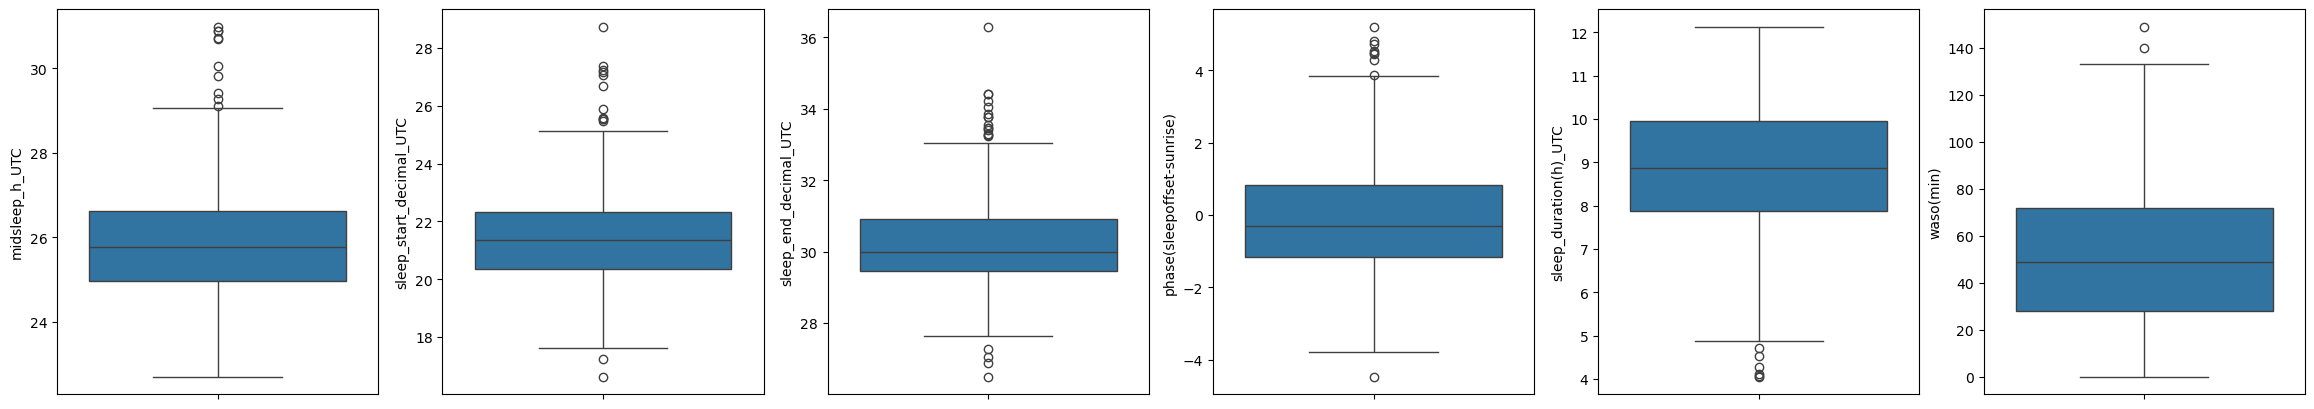

In [5]:
# box plot to verify the outliers
fig, ax = plt.subplots(1, 6, figsize=(29, 5))
sns.boxplot(data=df['midsleep_h_UTC'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal_UTC'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal_UTC'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)_UTC'], ax=ax[4])
sns.boxplot(data=df['waso(min)'], ax=ax[5])

plt.show()

In [6]:
# in midsleep_h_UTC, start_sleep_decimal_UTC, end_sleep_decimal_UTC, sleep_duration_h_UTC, phase(sleepoffset-sunrise), waso_min there are outliers
# Remove outliers with z-score > 3 but don't remove the rows 
# add a missing value instead of the cell value that is an outlier
#df['midsleep_h_UTC'] = df['midsleep_h_UTC'].mask((np.abs(stats.zscore(df['midsleep_h_UTC'])) > 3))
#df['sleep_start_decimal_UTC'] = df['sleep_start_decimal_UTC'].mask((np.abs(stats.zscore(df['sleep_start_decimal_UTC'])) > 3))
#df['sleep_end_decimal_UTC'] = df['sleep_end_decimal_UTC'].mask((np.abs(stats.zscore(df['sleep_end_decimal_UTC'])) > 3))
#df['phase(sleepoffset-sunrise)'] = df['phase(sleepoffset-sunrise)'].mask((np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) > 3))
#df['sleep_duration(h)_UTC'] = df['sleep_duration(h)_UTC'].mask((np.abs(stats.zscore(df['sleep_duration(h)_UTC'])) > 3))
#df['waso(min)'] = df['waso(min)'].mask((np.abs(stats.zscore(df['waso(min)'])) > 3))

# (option 2) remove outliers
# criteria: zscore of 3 means that the data point is 3 standard deviations away from the mean
#df = df[(np.abs(stats.zscore(df['midsleep_h_UTC'])) < 3)]
#df = df[(np.abs(stats.zscore(df['sleep_start_decimal_UTC'])) < 3)]
#df = df[(np.abs(stats.zscore(df['sleep_end_decimal_UTC'])) < 3)]
#df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]
#df = df[(np.abs(stats.zscore(df['sleep_duration(h)_UTC'])) < 3)]


In [7]:
# define the start date
start_date = pd.to_datetime('2022-02-01')

In [8]:
# function to count the week of the year from the start date 2022-02-01
def calculate_week_of_year(start_datetime): return (start_datetime - start_date).days // 7 + 5

# apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [9]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [10]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [11]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)_UTC'] = df['sleep_duration(h)_UTC'].astype(float)
df['sleep_duration_work_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'free days')

In [12]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [13]:
# create a new df for weekly jetlag analysis
data_jetlag_UTC = df 

In [14]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag_UTC = data_jetlag_UTC.groupby(['location', 'week_of_year', 'weekday_type'])['midsleep_h_UTC'].mean().unstack()

In [15]:
# calculate the jet lag for week and weekday
weekly_means_jetlag_UTC['jet lag_UTC'] = weekly_means_jetlag_UTC['free days'] - weekly_means_jetlag_UTC['work days']

In [16]:
# add a column with the location to the weekly_means_jetlag_UTC
weekly_means_jetlag_UTC['location'] = weekly_means_jetlag_UTC.index.get_level_values(0)

In [17]:
# save the weekly_means_jetlag_UTC to an excel file
weekly_means_jetlag_UTC.to_excel(fpath + '\\weekly_means_jetlag_UTC.xlsx')

In [18]:
# rename columns
df = df.rename(columns={'sleep_duration(h)_UTC': 'sleep_duration_UTC'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})
df = df.rename(columns={'waso(min)': 'waso'})
df = df.rename(columns={'DST(0=ST)': 'DST_0'})

In [19]:
# Adding a 'season' column to the dataset based on the 'date' column
# Defining seasons based on months: 
# Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)
def assign_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [20]:
# Applying the function to create a season column
df_workdays['season'] = df_workdays['date'].apply(assign_season)
df_freedays['season'] = df_freedays['date'].apply(assign_season)
df['season'] = df['date'].apply(assign_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_11180\2974399819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays['season'] = df_workdays['date'].apply(assign_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_11180\2974399819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays['season'] = df_freedays['date'].apply(assign_season)


In [21]:
# new variable 'photoperiod' based on the location
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])

In [22]:
# add a column with the photoperiod for the UK and ITA
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] 
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_11180\1608732957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)']


In [23]:
# add the photoperiod column to the df_freedays
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_11180\2381324628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


In [24]:
# descpriptive statistics
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [25]:
# add the index as a column
all_descriptive['variable'] = all_descriptive.index 

#reset the index
all_descriptive = all_descriptive.reset_index(drop=True)

In [26]:
all_descriptive.to_excel(fpath + '\\all_descriptive.xlsx')

In [27]:
# descpriptive statistics for ITA
descriptive_ita = df[df['location'] == 'ITA'].describe()
descriptive_ita = descriptive_ita.transpose()

In [28]:
descriptive_ita.to_excel(fpath + '\\descriptive_ita.xlsx')

In [29]:
# descpriptive statistics for UK
descriptive_uk = df[df['location'] == 'UK'].describe()
descriptive_uk = descriptive_uk.transpose()

In [30]:
descriptive_uk.to_excel(fpath + '\\descriptive_uk.xlsx')

In [31]:
# % of time spent in each location
count_location = df['location'].value_counts(normalize=True) * 100

In [32]:
count_location

location
ITA    57.99373
UK     42.00627
Name: proportion, dtype: float64

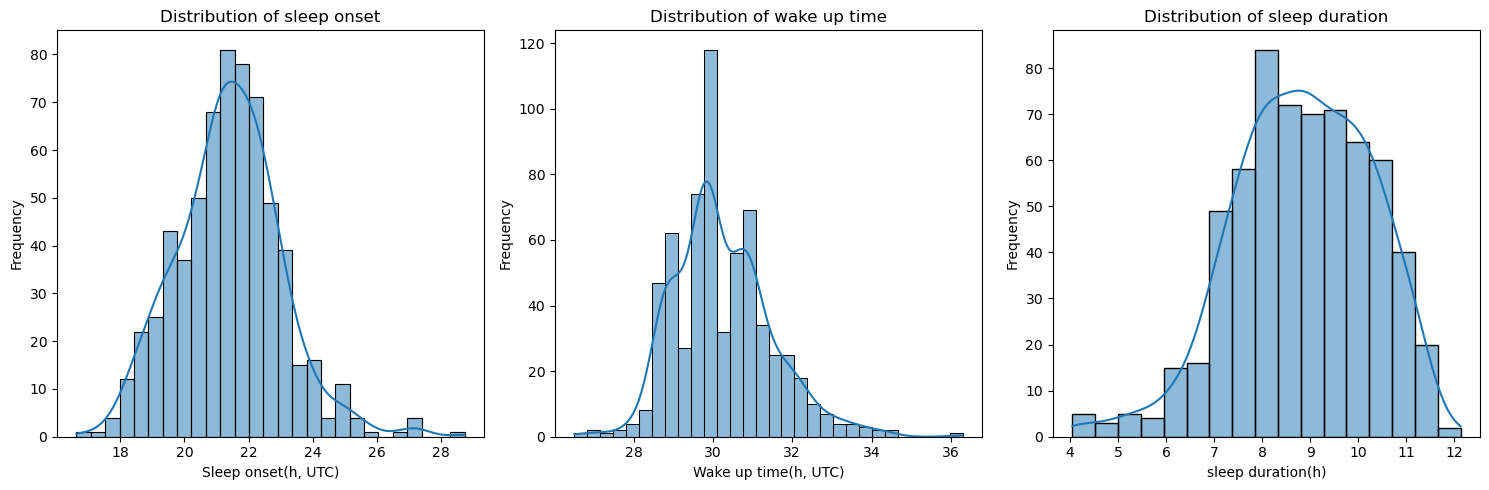

In [33]:
# distribution of the midpoint, sleep onset, sleep offset, and sleep duration
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of wake up time")
plt.xlabel("Wake up time(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

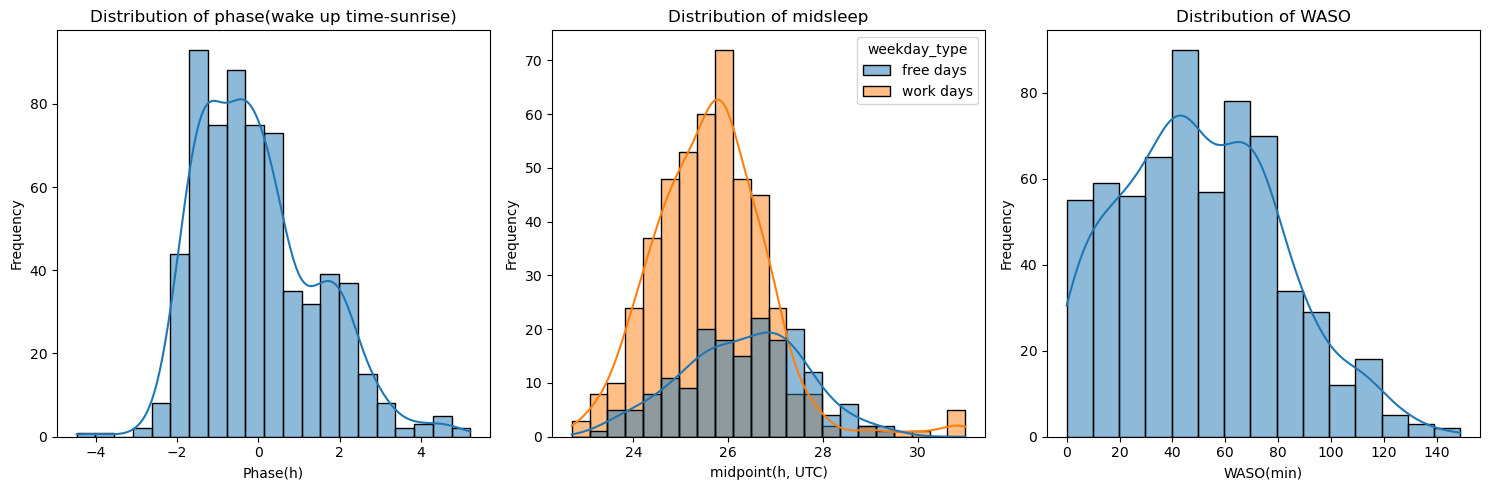

In [34]:
# distribution of phase and midpoint of sleep
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(wake up time-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='midsleep_h_UTC', hue='weekday_type', kde=True)
plt.title("Distribution of midsleep")
plt.xlabel("midpoint(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='waso', kde=True)
plt.title("Distribution of WASO")
plt.xlabel("WASO(min)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [35]:
# test normality of the data using Shapiro-Wilk test 
# Null hipotesis(H0): data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration_UTC'])
shapiro_test_midsleep = stats.shapiro(df['midsleep_h_UTC'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal_UTC'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal_UTC'])
shapiro_test_phase = stats.shapiro(df['phase'])
shapiro_test_waso = stats.shapiro(df['waso'].dropna())

In [36]:
shapiro_results_x = pd.DataFrame({
    'Variable': ['sleep_duration(h)', 'midsleep_h_UTC', 'sleep_start_decimal_UTC', 'sleep_end_decimal_UTC', 'phase(sleepoffset-sunrise)', 'waso(min)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midsleep, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase, shapiro_test_waso]
})

In [37]:
shapiro_results_x

,Variable,Shapiro-Wilk test
0,sleep_duration(h),"(0.9837055273908211, 1.5120670601530125e-06)"
1,midsleep_h_UTC,"(0.9754490672711128, 7.340203633940609e-09)"
2,sleep_start_decimal_UTC,"(0.9845491253013061, 2.8127336831035202e-06)"
3,sleep_end_decimal_UTC,"(0.9685820023206414, 1.8694967668436876e-10)"
4,phase(sleepoffset-sunrise),"(0.9604101854751472, 4.355781406099288e-12)"
5,waso(min),"(0.9799029640660145, 1.2363375451912618e-07)"


In [38]:
# test normality of the data using Shapiro-Wilk test for work days and free days (midpoint of sleep)
shapiro_test_midpoint_free = stats.shapiro(df[df['weekday_type'] == 'free days']['midsleep_h_UTC'])
shapiro_test_midpoint_work = stats.shapiro(df[df['weekday_type'] == 'work days']['midsleep_h_UTC'])

In [39]:
shapiro_results_free_work = pd.DataFrame({
    'Weekday type': ['free days', 'work days'],
    'Shapiro-Wilk test': [shapiro_test_midpoint_free, shapiro_test_midpoint_work]
})

In [40]:
shapiro_results_free_work

,Weekday type,Shapiro-Wilk test
0,free days,"(0.9931751931676394, 0.575414620081543)"
1,work days,"(0.9448112356731146, 4.675779748247053e-12)"


__General trends and variability in sleep patterns__

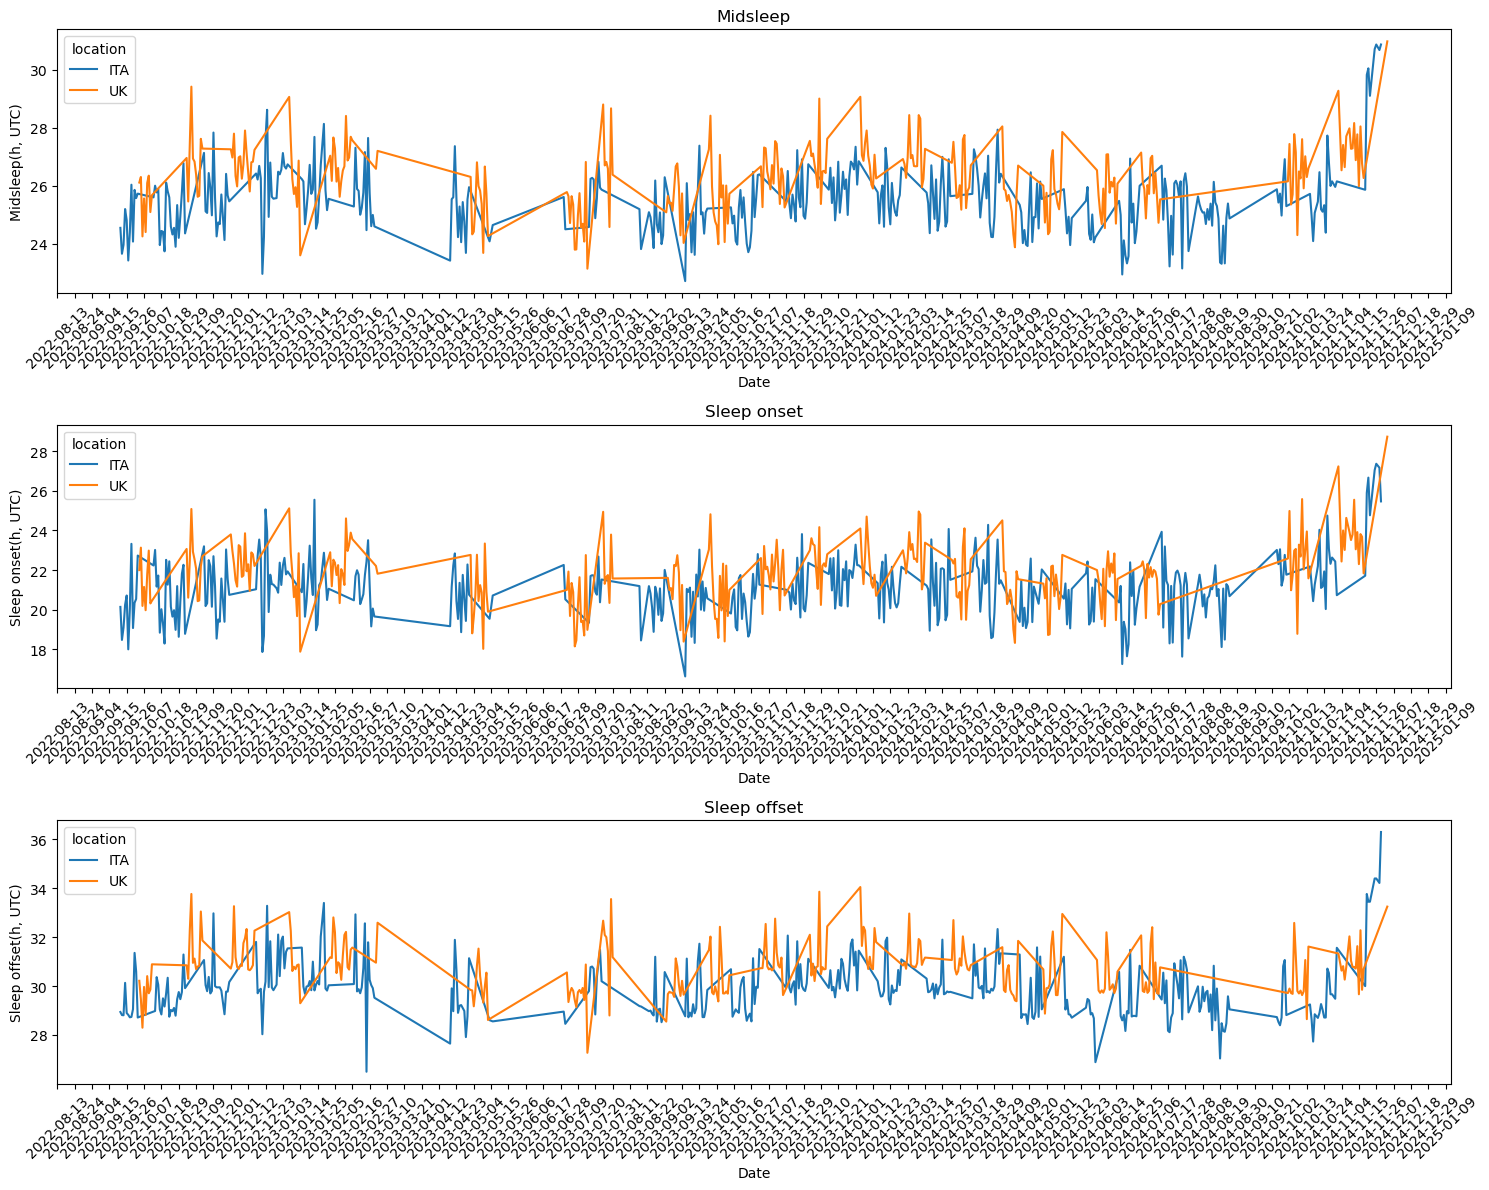

In [41]:
plt.figure(figsize=(15, 15))
plt.subplot(4, 1, 1)
sns.lineplot(data=df, x='date', y='midsleep_h_UTC', hue='location')
plt.title("Midsleep")
plt.xlabel("Date")
plt.ylabel("Midsleep(h, UTC)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.subplot(4, 1, 2)
sns.lineplot(data=df, x='date', y='sleep_start_decimal_UTC', hue='location')
plt.title("Sleep onset")
plt.xlabel("Date")
plt.ylabel("Sleep onset(h, UTC)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.subplot(4, 1, 3)
sns.lineplot(data=df, x='date', y='sleep_end_decimal_UTC', hue='location')
plt.title("Sleep offset")
plt.xlabel("Date")
plt.ylabel("Sleep offset(h, UTC)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.tight_layout()
plt.show()

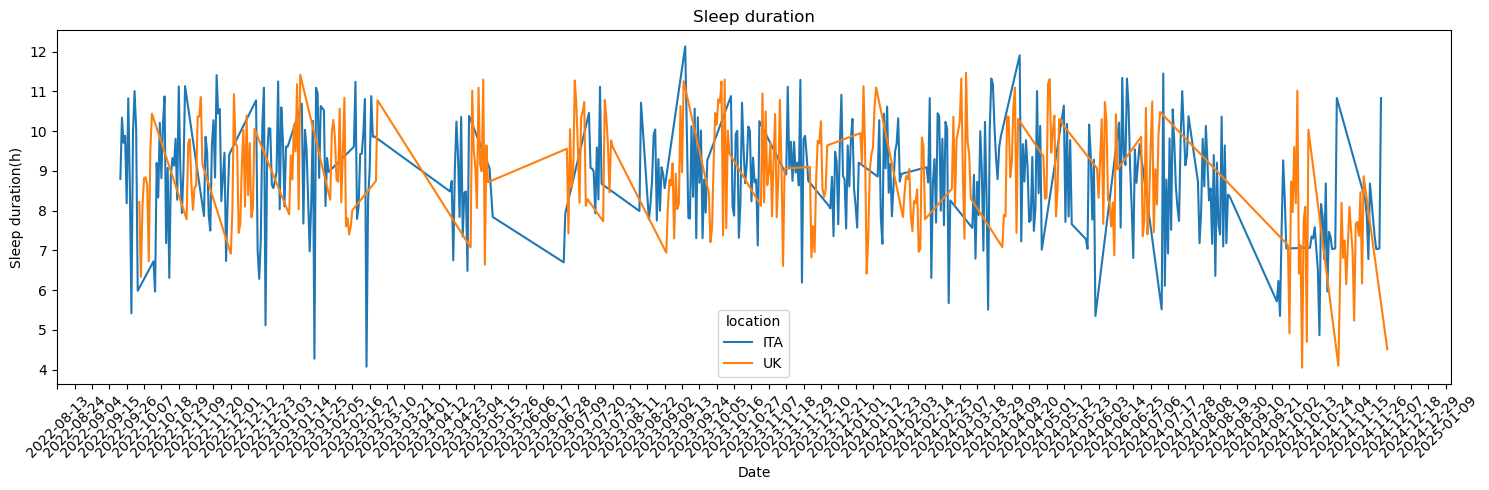

In [42]:
plt.figure(figsize=(15, 5))
sns.lineplot(data=df, x='date', y='sleep_duration_UTC', hue='location')
plt.title("Sleep duration")
plt.xlabel("Date")
plt.ylabel("Sleep duration(h)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.tight_layout()
plt.show()

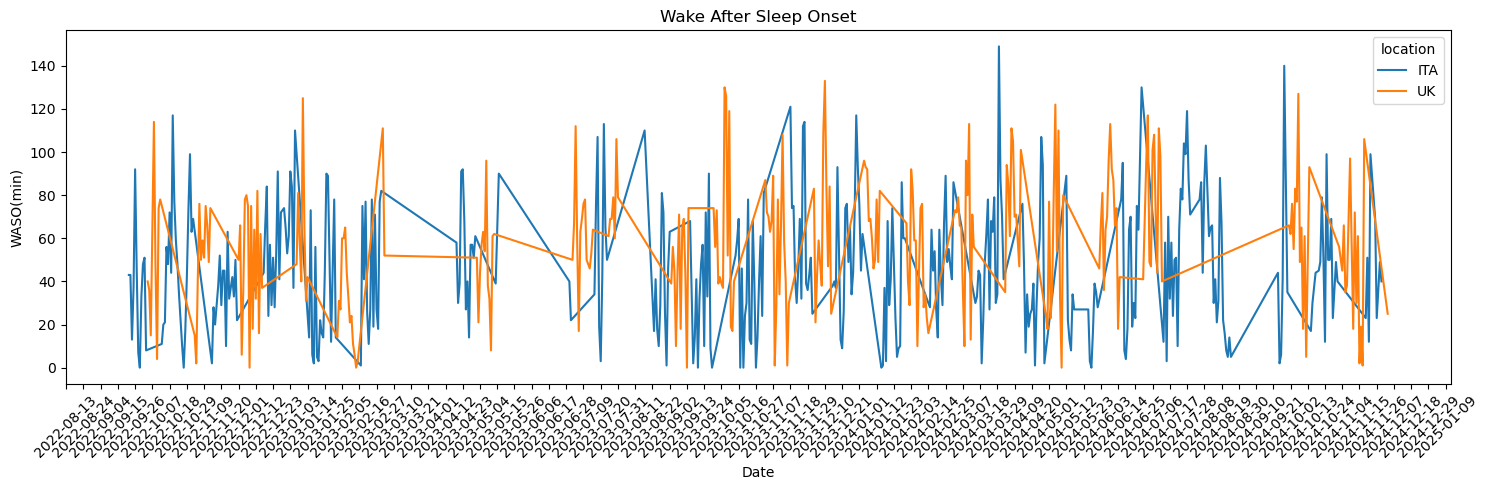

In [43]:
plt.figure(figsize=(15, 5))
sns.lineplot(data=df, x='date', y='waso', hue='location')
plt.title("Wake After Sleep Onset")
plt.xlabel("Date")
plt.ylabel("WASO(min)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.tight_layout()
plt.show()

In [44]:
#df['date'] = pd.to_datetime(df['date'])

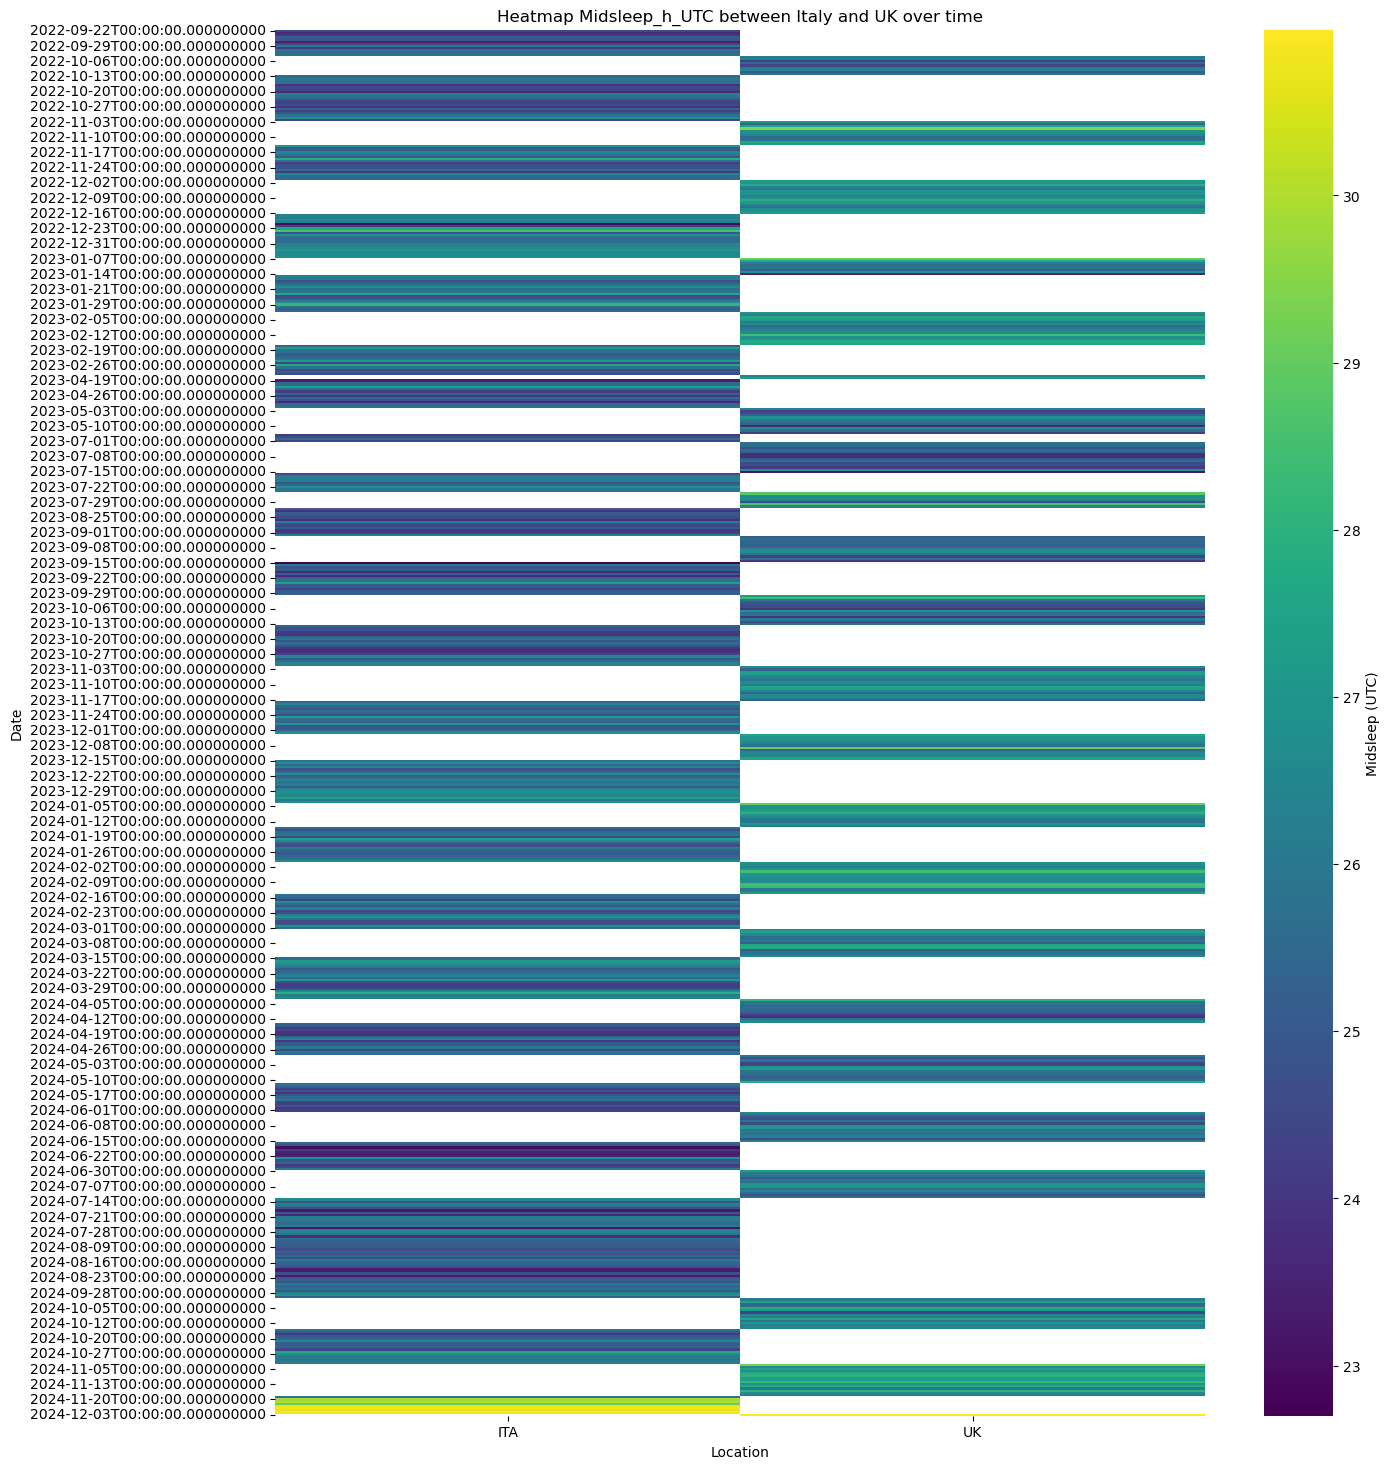

In [45]:
plt.figure(figsize=(15, 18))
df_pivot = df.pivot_table(index='date', columns='location', values='midsleep_h_UTC')
sns.heatmap(df_pivot, cmap="viridis", cbar_kws={'label': 'Midsleep (UTC)'})
plt.title('Heatmap Midsleep_h_UTC between Italy and UK over time')
plt.xlabel('Location')
plt.ylabel('Date')

plt.show()

__Sleep-wake pattern between Uk and Italy__

In [46]:
# descriptive statistics by location
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [47]:
# compare the variables between ITA and UK
ttest_midsleep_all_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midsleep_h_UTC'], df[df['location'] == 'UK']['midsleep_h_UTC'])
ttest_midsleep_workdays_loc = stats.ttest_ind(df_workdays[df_workdays['location'] == 'ITA']['midsleep_h_UTC'], df_workdays[df_workdays['location'] == 'UK']['midsleep_h_UTC'])
ttest_midsleep_freedays_loc = stats.ttest_ind(df_freedays[df_freedays['location'] == 'ITA']['midsleep_h_UTC'], df_freedays[df_freedays['location'] == 'UK']['midsleep_h_UTC'])
ttest_duration_loc = stats.ttest_ind(df[df['location'] == 'ITA']['sleep_duration_UTC'], df[df['location'] == 'UK']['sleep_duration_UTC'])
ttest_start_loc = stats.ttest_ind(df[df['location'] == 'ITA']['sleep_start_decimal_UTC'], df[df['location'] == 'UK']['sleep_start_decimal_UTC'])

utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal_UTC'], df[df['location'] == 'UK']['sleep_end_decimal_UTC'])
utest_waso_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['waso'].dropna(), df[df['location'] == 'UK']['waso'].dropna())

In [48]:
# print the results
print('T test results by location')
print('Midsleep_all:', ttest_midsleep_all_loc)
print('Midsleep_work:', ttest_midsleep_workdays_loc)
print('Midsleep_free:', ttest_midsleep_freedays_loc)
print('Sleep_onset:', ttest_start_loc)
print('Sleep_duration:', ttest_duration_loc)
print('U test results by location')
print('Sleep_offset:', utest_end_loc)
print('Phase:', utest_phase_loc)
print('WASO:', utest_waso_loc)

T test results by location
Midsleep_all: TtestResult(statistic=-8.473776377936943, pvalue=1.6517285458040164e-16, df=636.0)
Midsleep_work: TtestResult(statistic=-6.451189811154685, pvalue=2.826313274343099e-10, df=458.0)
Midsleep_free: TtestResult(statistic=-6.196651769964136, pvalue=3.9726037789597335e-09, df=176.0)
Sleep_onset: TtestResult(statistic=-6.128895698007683, pvalue=1.5524367075433932e-09, df=636.0)
Sleep_duration: TtestResult(statistic=-0.5188605023806983, pvalue=0.6040385084091762, df=636.0)
U test results by location
Sleep_offset: MannwhitneyuResult(statistic=28130.5, pvalue=1.0163151881709591e-20)
Phase: MannwhitneyuResult(statistic=28892.5, pvalue=2.2036575826545703e-19)
WASO: MannwhitneyuResult(statistic=38207.5, pvalue=3.0254981455795103e-06)


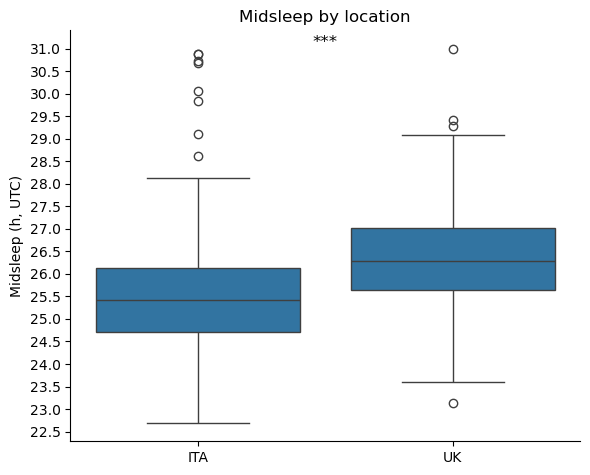

In [49]:
# plot the midpoint of sleep by location
plt.figure(figsize=(6, 5))
sns.boxplot(x='location', y='midsleep_h_UTC', data=df)
plt.title('Midsleep by location')
plt.suptitle('')  
plt.xlabel('')
plt.ylabel('Midsleep (h, UTC)')

plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.5)) # gcd stands for 'get current axis'
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

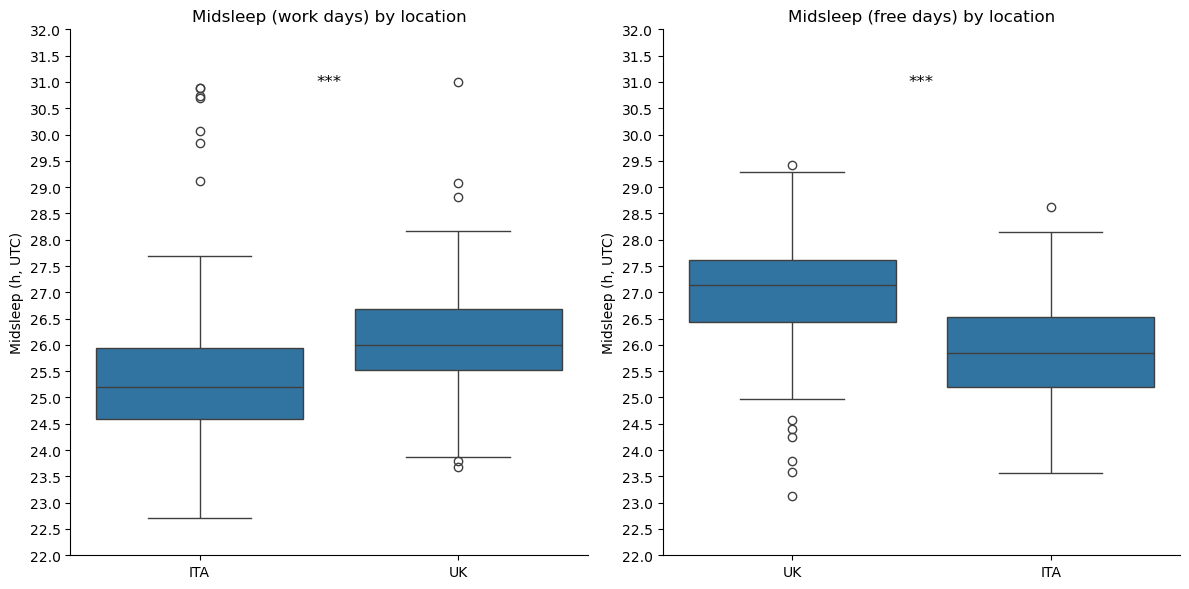

In [50]:
# plot the midpoint of sleep by location for free days and work days
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='location', y='midsleep_h_UTC', data=df_workdays, ax=ax[0])
ax[0].set_title('Midsleep (work days) by location')
ax[0].set_ylabel('Midsleep (h, UTC)')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_locator(MultipleLocator(0.5))
ax[0].set_ylim(22, 32)
ax[0].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line of ** for the p-value < 0.001

sns.boxplot(x='location', y='midsleep_h_UTC', data=df_freedays, ax=ax[1])
ax[1].set_title('Midsleep (free days) by location')
ax[1].set_ylabel('Midsleep (h, UTC)')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_locator(MultipleLocator(0.5))
ax[1].set_ylim(ax[0].get_ylim())
ax[1].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line of  for the p-value < 0.001
ax[1].invert_xaxis()
     
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.tight_layout()
plt.show()

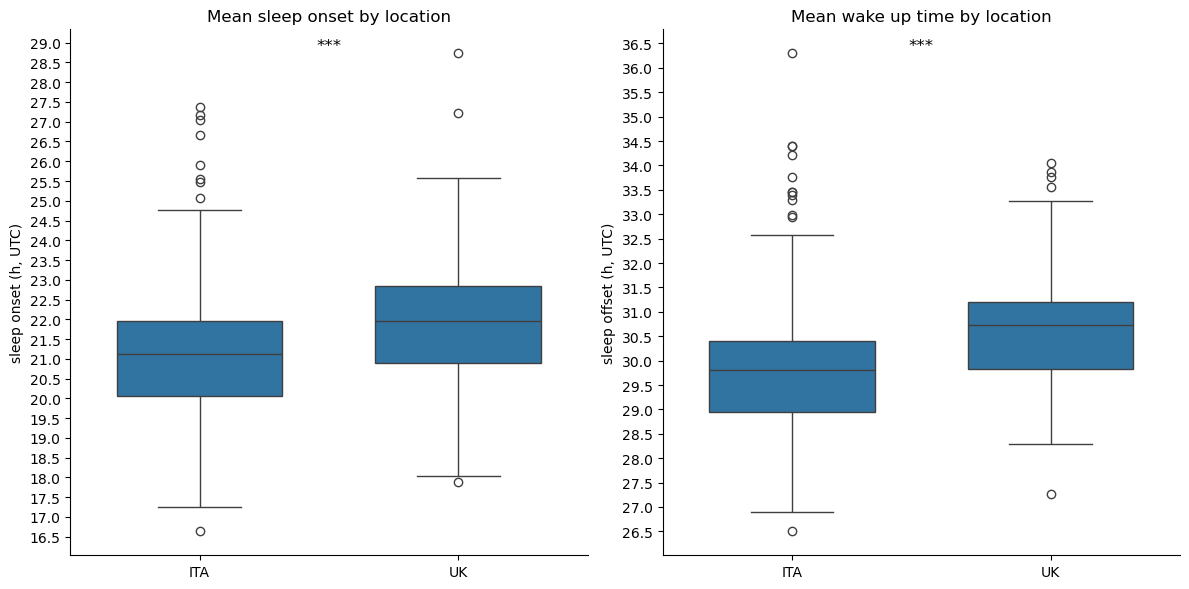

In [51]:
# plot the sleep onset and sleep offset by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal_UTC', data=df, gap=0.2)
plt.title('Mean sleep onset by location')
plt.xlabel('')
plt.ylabel('sleep onset (h, UTC)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal_UTC', data=df, gap=0.2)
plt.title('Mean wake up time by location')
plt.xlabel('')
plt.ylabel('sleep offset (h, UTC)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

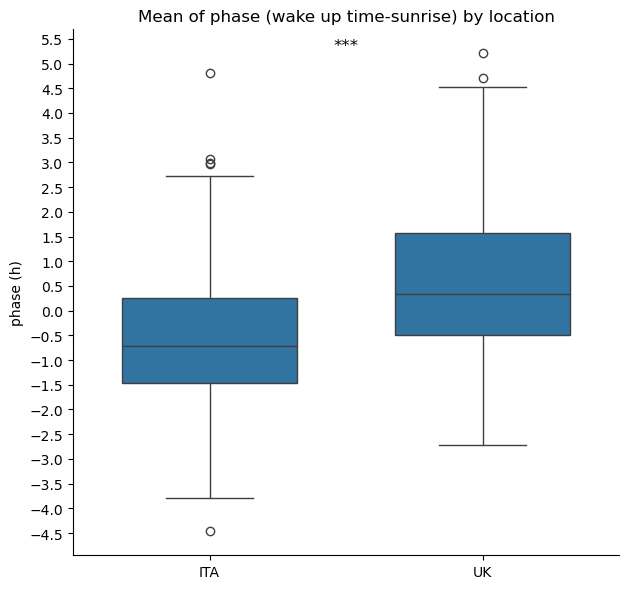

In [52]:
# plot the phase (sleep offset-sunrise) by location 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='phase', data=df, gap=0.2)
plt.title('Mean of phase (wake up time-sunrise) by location')
plt.xlabel('')
plt.ylabel('phase (h)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

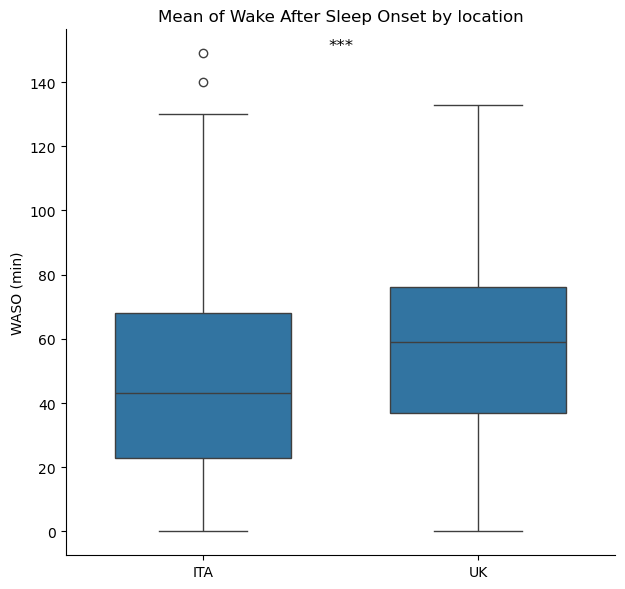

In [53]:
# plot the waso by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='waso', data=df, gap=0.2)
plt.title('Mean of Wake After Sleep Onset by location')
plt.xlabel('')
plt.ylabel('WASO (min)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
#plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

__Jet lag__

In [54]:
# drop the rows with missing values
jetlag_clean = weekly_means_jetlag_UTC['jet lag_UTC'].dropna()

In [55]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_clean)

In [56]:
print('Shapiro test result for jet lag:')
print(shapiro_test_jetlag)

Shapiro test result for jet lag:
ShapiroResult(statistic=0.9876371586205769, pvalue=0.4672089661380179)


In [57]:
# test the difference in jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'ITA']['jet lag_UTC'].dropna(), 
                               weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'UK']['jet lag_UTC'].dropna())

In [58]:
print('T test result for jet lag by location:')
print(ttest_jetlag)

T test result for jet lag by location:
TtestResult(statistic=-0.6360820960235657, pvalue=0.5261760751328164, df=100.0)


__Season and sleep-wake pattern__

In [59]:
# remove NaN values from the columns and create a new dataframe
df1 = df.dropna(subset=['sleep_duration_UTC']) 
df2 = df.dropna(subset=['phase'])
df3 = df.dropna(subset=['waso'])

In [60]:
anova_ols_midsleep_season = ols('midsleep_h_UTC ~ C(season)', data=df).fit() # generate and fit the regression model
anova_results_midsleep = sm.stats.anova_lm(anova_ols_midsleep_season, typ=3) # fit the ANOVA model and get the results

In [61]:
print('ANOVA Result for midsleep:')
print(anova_results_midsleep)

ANOVA Result for midsleep:
                  sum_sq     df              F        PR(>F)
Intercept  147035.016573    1.0  100933.305701  0.000000e+00
C(season)      92.903749    3.0      21.258162  3.937431e-13
Residual      923.582160  634.0            NaN           NaN


In [62]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df['midsleep_h_UTC'], df['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   -0.339 0.0706 -0.6967 0.0188  False
Autumn Summer    -0.55 0.0003    -0.9   -0.2   True
Autumn Winter   0.4889 0.0004  0.1764 0.8014   True
Spring Summer   -0.211 0.5328 -0.6143 0.1923  False
Spring Winter   0.8279    0.0  0.4568  1.199   True
Summer Winter   1.0389    0.0  0.6752 1.4026   True
---------------------------------------------------


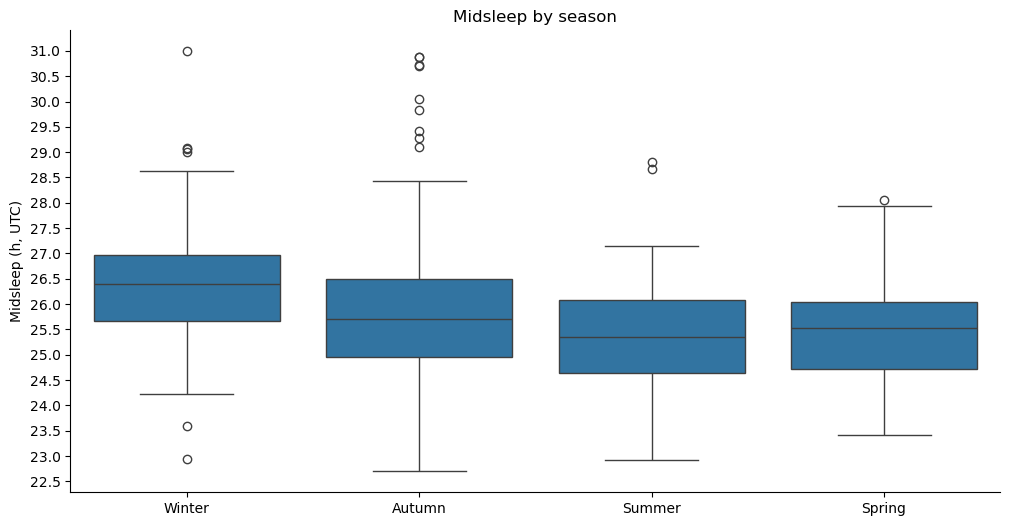

In [63]:
# Midsleep by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midsleep_h_UTC', data=df)
plt.title('Midsleep by season')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Midsleep (h, UTC)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black') 
plt.gca().spines['left'].set_color('black')
plt.show()

In [64]:
anova_sleep_duration_season = ols('sleep_duration_UTC ~ C(season)', data=df1).fit()
anova_results_sleep_duration = sm.stats.anova_lm(anova_sleep_duration_season, typ=2)

print('ANOVA Result for sleep duration:')
print(anova_results_sleep_duration)

ANOVA Result for sleep duration:
                sum_sq     df         F    PR(>F)
C(season)    21.927765    3.0  3.626965  0.012875
Residual   1277.670758  634.0       NaN       NaN


In [65]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df1['sleep_duration_UTC'], df1['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.4896  0.015  0.0688 0.9103   True
Autumn Summer   0.3352 0.1551 -0.0765 0.7469  False
Autumn Winter   0.3138 0.1244 -0.0537 0.6813  False
Spring Summer  -0.1544 0.8362 -0.6287   0.32  False
Spring Winter  -0.1757 0.7278 -0.6123 0.2608  False
Summer Winter  -0.0214 0.9992 -0.4491 0.4064  False
---------------------------------------------------


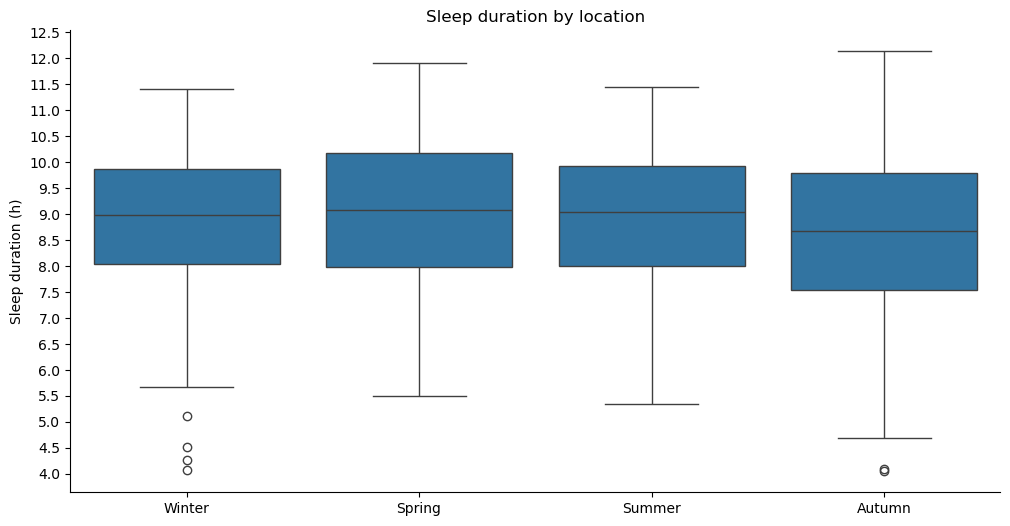

In [66]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_duration_UTC', data=df1, order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Sleep duration by location')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Sleep duration (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black') 
plt.gca().spines['left'].set_color('black')
plt.show()

In [67]:
anova_start_season = ols('sleep_start_decimal_UTC ~ C(season)', data=df).fit()
anova_results_start = sm.stats.anova_lm(anova_start_season, typ=2)

print('ANOVA results for sleep onset:')
print(anova_results_start)

ANOVA results for sleep onset:
                sum_sq     df         F        PR(>F)
C(season)   108.030014    3.0  14.19366  5.803650e-09
Residual   1608.488739  634.0       NaN           NaN


In [68]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df['sleep_start_decimal_UTC'], df['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring  -0.5838 0.0082 -1.0559 -0.1117   True
Autumn Summer  -0.7176 0.0004 -1.1795 -0.2557   True
Autumn Winter    0.332 0.1628 -0.0804  0.7444  False
Spring Summer  -0.1338 0.9164  -0.666  0.3984  False
Spring Winter   0.9158    0.0   0.426  1.4056   True
Summer Winter   1.0496    0.0  0.5696  1.5296   True
----------------------------------------------------


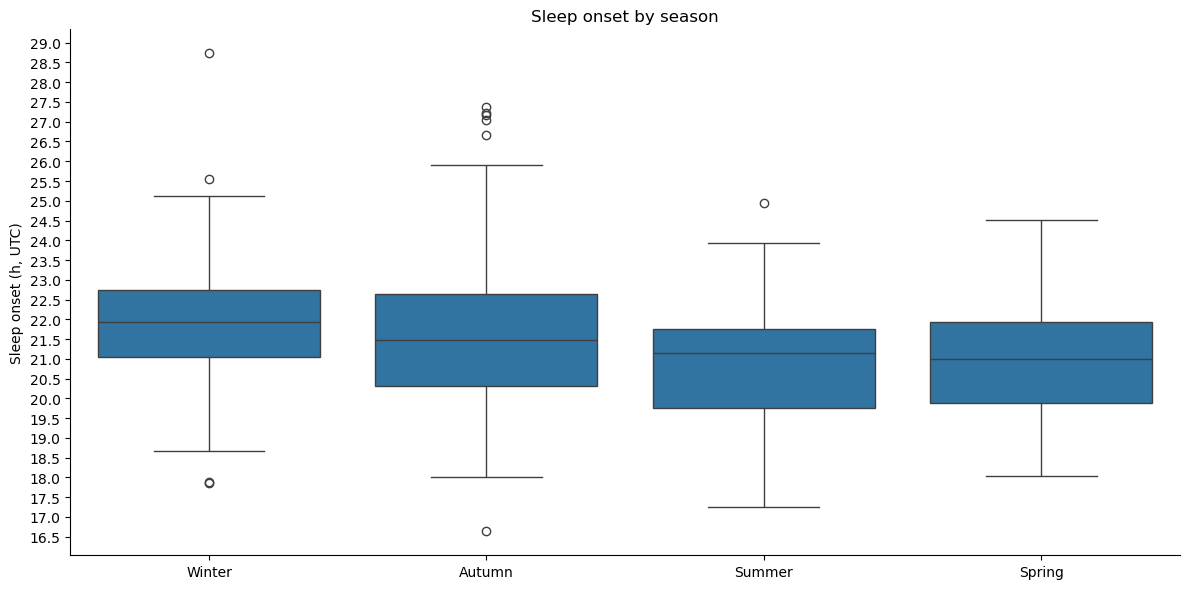

In [69]:
# sleep onset and offset by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_start_decimal_UTC', data=df)
plt.title('Sleep onset by season')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

In [70]:
# perform a Kruskal-Wallis test to compare the phase, sleep end and waso between the seasons
kw_phase_season = stats.kruskal(df2[df2['season'] == 'Winter']['phase'], df2[df2['season'] == 'Spring']['phase'], 
                                df2[df2['season'] == 'Summer']['phase'], df2[df2['season'] == 'Autumn']['phase'])

kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal_UTC'], df[df['season'] == 'Spring']['sleep_end_decimal_UTC'], 
                              df[df['season'] == 'Summer']['sleep_end_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_end_decimal_UTC'])

kw_waso_season = stats.kruskal(df3[df3['season'] == 'Winter']['waso'], df3[df3['season'] == 'Spring']['waso'], 
                               df3[df3['season'] == 'Summer']['waso'], df3[df3['season'] == 'Autumn']['waso'])

print('Kruskal-Wallis test results for phase:')
print(kw_phase_season)
print('Kruskal-Wallis test results for sleep end:')
print(kw_end_season)
print('Kruskal-Wallis test results for waso:')  
print(kw_waso_season)

Kruskal-Wallis test results for phase:
KruskalResult(statistic=208.25489838874873, pvalue=6.939555547409442e-45)
Kruskal-Wallis test results for sleep end:
KruskalResult(statistic=74.03450377569052, pvalue=5.834727097162549e-16)
Kruskal-Wallis test results for waso:
KruskalResult(statistic=10.399447151621382, pvalue=0.0154587514583372)


In [71]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df2['phase'], df2['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.1865    0.0  0.8289  1.5441   True
Autumn Summer   1.7183    0.0  1.3684  2.0682   True
Autumn Winter  -0.3958 0.0063 -0.7082 -0.0835   True
Spring Summer   0.5318  0.004  0.1286  0.9349   True
Spring Winter  -1.5824    0.0 -1.9534 -1.2113   True
Summer Winter  -2.1141    0.0 -2.4777 -1.7506   True
----------------------------------------------------


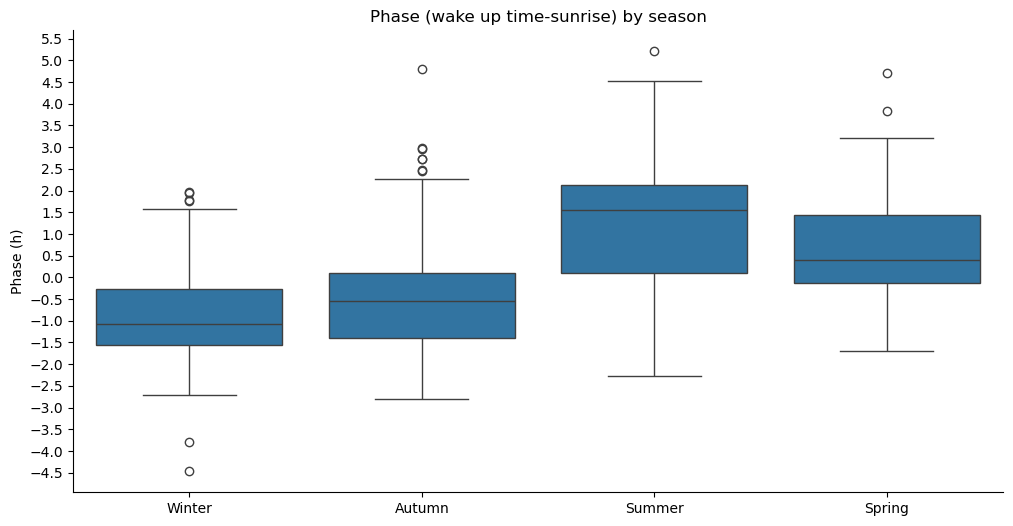

In [72]:
# phase (sleep offset - sunrise) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by season')
plt.suptitle('')  # add space after the title
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [73]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df['sleep_end_decimal_UTC'], df['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring  -0.0942 0.8986 -0.4429  0.2545  False
Autumn Summer  -0.3824 0.0209 -0.7236 -0.0412   True
Autumn Winter   0.6458    0.0  0.3413  0.9504   True
Spring Summer  -0.2882  0.234 -0.6813  0.1049  False
Spring Winter     0.74    0.0  0.3783  1.1018   True
Summer Winter   1.0282    0.0  0.6737  1.3827   True
----------------------------------------------------


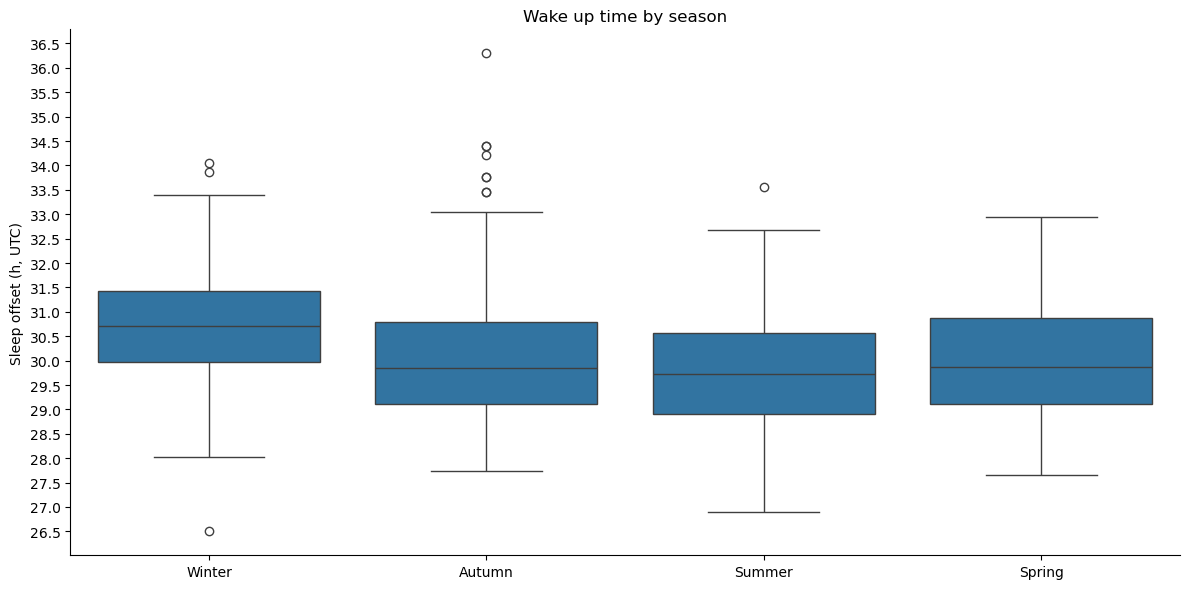

In [74]:
# sleep offset by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_end_decimal_UTC', data=df)
plt.title('Wake up time by season')
plt.ylabel('Sleep offset (h, UTC)')
plt.xlabel('')
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

In [75]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df3['waso'], df3['season'])
print(tukey_results_season)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
Autumn Spring   5.5168 0.3915   -3.484 14.5176  False
Autumn Summer  10.1008 0.0175   1.2727  18.929   True
Autumn Winter   0.6057 0.9972   -7.237  8.4485  False
Spring Summer    4.584 0.6513  -5.5803 14.7484  False
Spring Winter  -4.9111 0.5268 -14.2324  4.4102  False
Summer Winter  -9.4951 0.0387 -18.6499 -0.3404   True
-----------------------------------------------------


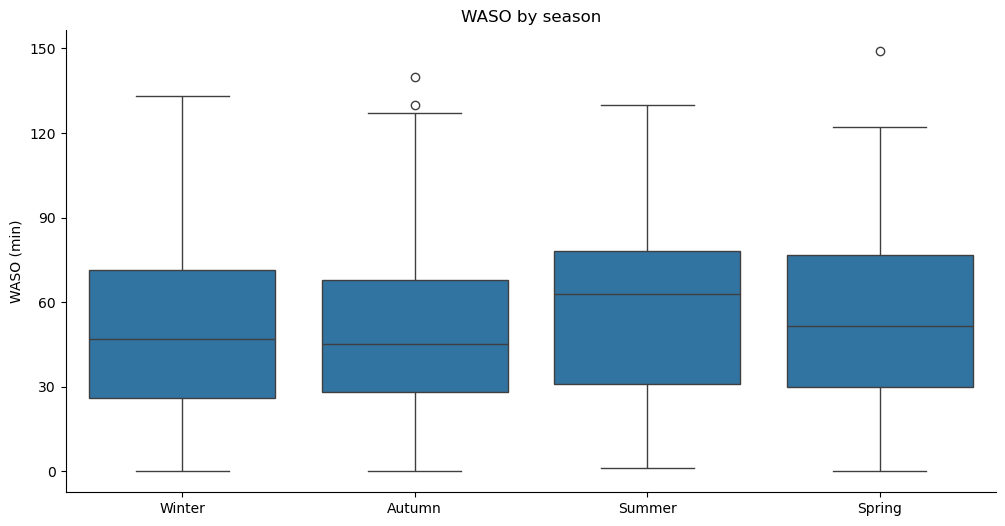

In [76]:
# waso by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='waso', data=df3)
plt.title('WASO by season')
plt.ylabel('WASO (min)')
plt.xlabel('')
plt.gca().yaxis.set_major_locator(MultipleLocator(30))

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)

plt.show()

__DST and sleep-wake pattern__

In [77]:
# t-test to compare the midpoint of sleep between DST and non-DST
ttest_midsleep_dst = stats.ttest_ind(df[df['DST_0'] == 0]['midsleep_h_UTC'], df[df['DST_0'] == 1]['midsleep_h_UTC'])
ttest_sleep_duration_dst = stats.ttest_ind(df1[df1['DST_0'] == 0]['sleep_duration_UTC'], df1[df1['DST_0'] == 1]['sleep_duration_UTC'])
ttest_sleep_start_dst = stats.ttest_ind(df[df['DST_0'] == 0]['sleep_start_decimal_UTC'], df[df['DST_0'] == 1]['sleep_start_decimal_UTC'])

utest_sleep_end_dst = stats.mannwhitneyu(df[df['DST_0'] == 0]['sleep_end_decimal_UTC'], df[df['DST_0'] == 1]['sleep_end_decimal_UTC'])
utest_phase_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['phase'], df2[df2['DST_0'] == 1]['phase'])
utest_waso_dst = stats.mannwhitneyu(df3[df3['DST_0'] == 0]['waso'], df3[df3['DST_0'] == 1]['waso'])

In [78]:
print('T test result for the midsleep by DST:')
print(ttest_midsleep_dst)
print('T test result for the sleep duration by DST:')
print(ttest_sleep_duration_dst)
print('T test result for the sleep onset by DST:')
print(ttest_sleep_start_dst)
print('U test result for the sleep offset by DST:')
print(utest_sleep_end_dst)
print('U test result for the phase by DST:')
print(utest_phase_dst)
print('U test result for the waso by DST:')
print(utest_waso_dst)

T test result for the midsleep by DST:
TtestResult(statistic=11.838114240674459, pvalue=2.327796871218004e-29, df=636.0)
T test result for the sleep duration by DST:
TtestResult(statistic=0.6063427161078875, pvalue=0.54450355271798, df=636.0)
T test result for the sleep onset by DST:
TtestResult(statistic=8.415451286020929, pvalue=2.5875899689642716e-16, df=636.0)
U test result for the sleep offset by DST:
MannwhitneyuResult(statistic=79162.0, pvalue=2.443156139001102e-34)
U test result for the phase by DST:
MannwhitneyuResult(statistic=31100.0, pvalue=2.842663770319165e-17)
U test result for the waso by DST:
MannwhitneyuResult(statistic=49678.0, pvalue=0.8952698722966661)


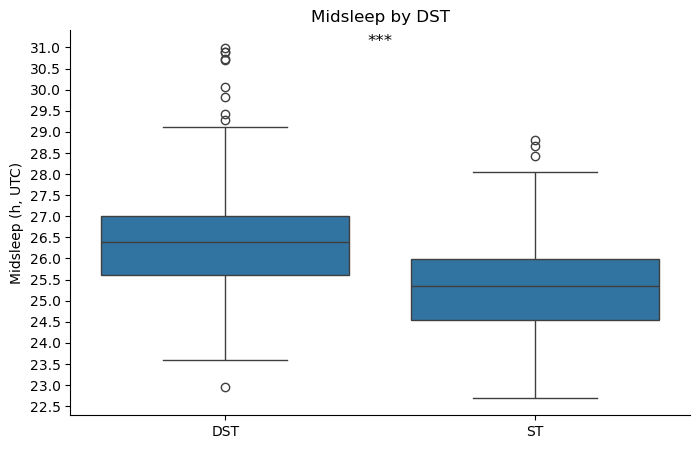

In [79]:
# Midsleep by DST
plt.figure(figsize=(8, 5))
sns.boxplot(x='DST_0', y='midsleep_h_UTC', data=df)
plt.title('Midsleep by DST')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midsleep (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
sns.despine()
plt.grid(False)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

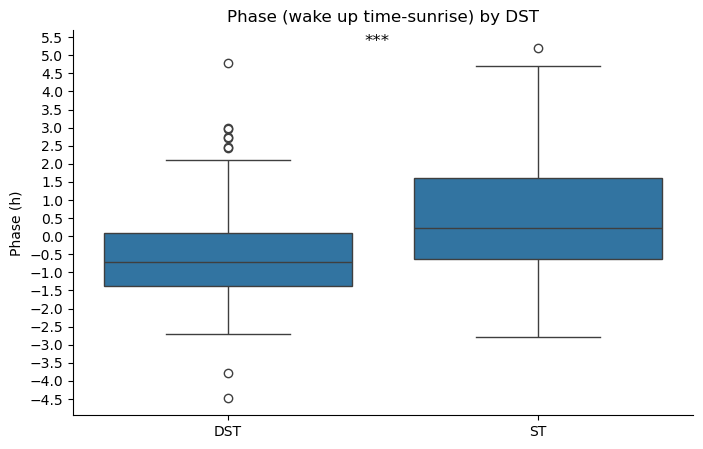

In [80]:
# phase (sleep offset - sunrise) by DST
plt.figure(figsize=(8, 5))
sns.boxplot(x='DST_0', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by DST')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('***', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

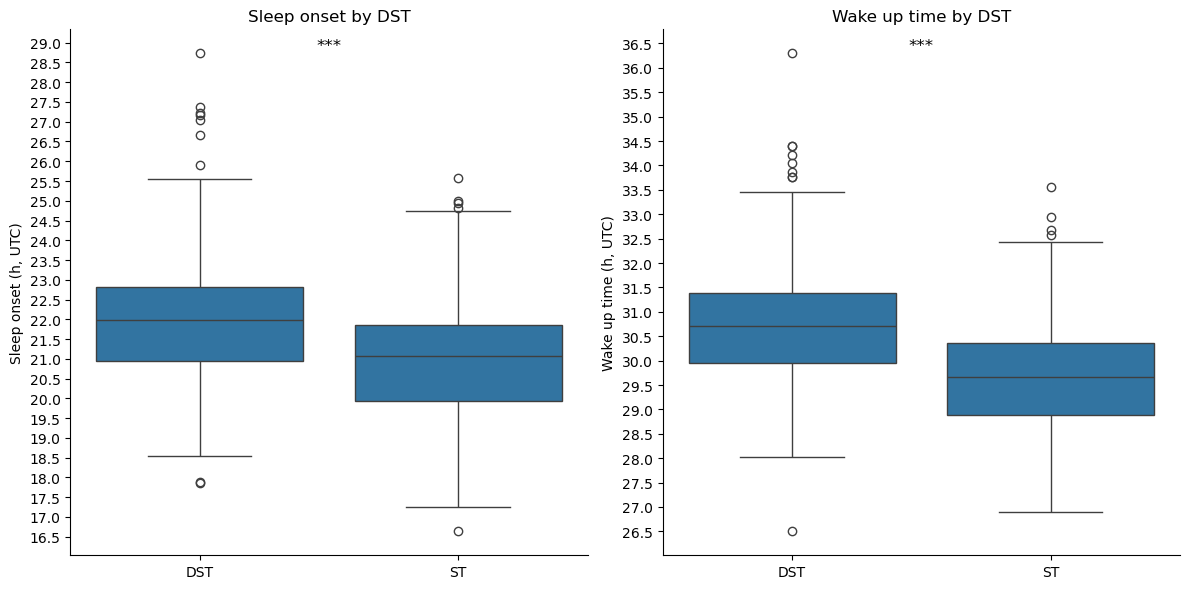

In [81]:
# sleep onset and offset by DST
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='DST_0', y='sleep_start_decimal_UTC', data=df)
plt.title('Sleep onset by DST')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.subplot(1, 2, 2)
sns.boxplot(x='DST_0', y='sleep_end_decimal_UTC', data=df)
plt.title('Wake up time by DST')
plt.ylabel('Wake up time (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

__Photoperiod and sleep-wake pattern__

In [82]:
# correlation between sleep-wake variables and photoperiod
correlation_test1 = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
correlation_test2 = stats.pearsonr(df_workdays['midsleep_h_UTC'], df_workdays['photoperiod'])
correlation_test3 = stats.pearsonr(df_freedays['midsleep_h_UTC'], df_freedays['photoperiod'])
correlation_test4 = stats.pearsonr(df2['sleep_duration_UTC'], df2['photoperiod'])

# correlation between sleep-wake variables and photoperiod using Spearman's rank correlation
correlation_test5 = stats.spearmanr(df['sleep_end_decimal_UTC'], df['photoperiod'])
correlation_test6 = stats.spearmanr(df3['waso'], df3['photoperiod'])

In [83]:
# extract the coefficients and p-values from the correlation test results
correlation_coeff = [correlation_test1.statistic, correlation_test2.statistic, correlation_test3.statistic, 
                     correlation_test4.statistic, correlation_test5.statistic, correlation_test6.statistic]

p_values = [correlation_test1.pvalue, correlation_test2.pvalue, correlation_test3.pvalue, 
            correlation_test4.pvalue, correlation_test5.pvalue, correlation_test6.pvalue]

In [84]:
# create a DataFrame with the results
correlation_results = pd.DataFrame({
    'Variables': ['midsleep UTC vs photoperiod', 'midsleep (work) UTC vs photoperiod', 'midsleep (free) UTC vs photoperiod', 
                  'sleep duration UTC vs photoperiod', 'sleep offset UTC vs photoperiod', 'WASO(min) vs photoperiod'],
    'Coefficient': correlation_coeff,
    'P-value': p_values
})

correlation_results

,Variables,Coefficient,P-value
0,midsleep UTC vs photoperiod,-0.359571,6.596644e-21
1,midsleep (work) UTC vs photoperiod,-0.383248,1.527238e-17
2,midsleep (free) UTC vs photoperiod,-0.349874,1.691348e-06
3,sleep duration UTC vs photoperiod,0.045240,2.538543e-01
4,sleep offset UTC vs photoperiod,-0.378595,3.563612e-23
5,WASO(min) vs photoperiod,0.047958,2.282396e-01


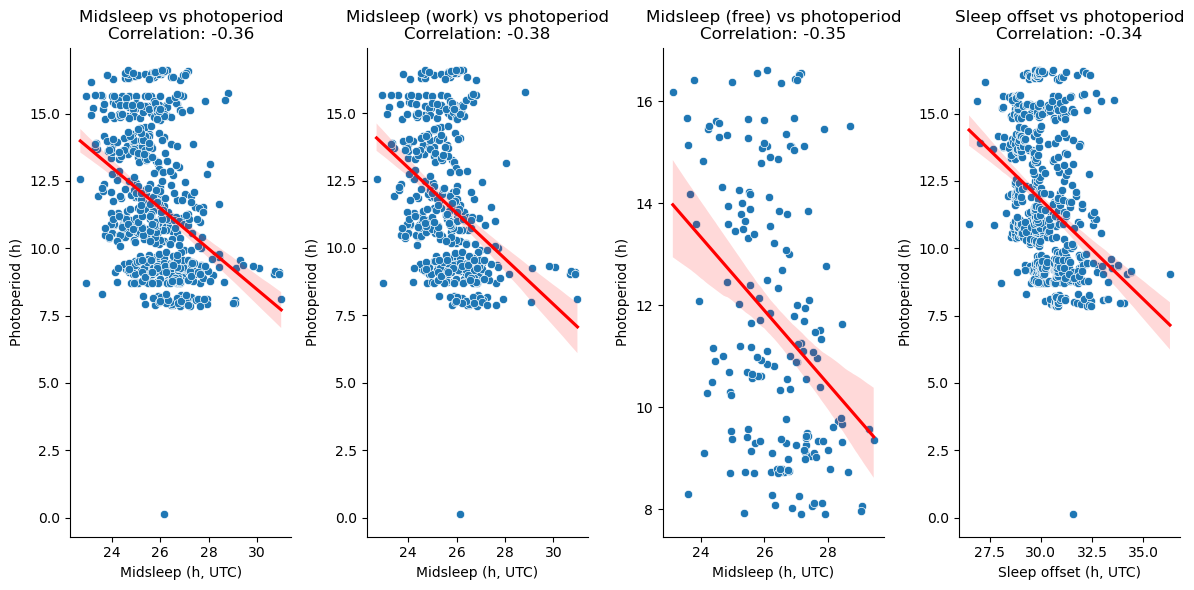

In [85]:
# plot the correlation between the midpoint of sleep and photoperiod, for all the data, work days and free days
plt.figure(figsize=(12, 6))

# All data
plt.subplot(1, 4, 1)
sns.scatterplot(x='midsleep_h_UTC', y='photoperiod', data=df)
sns.regplot(x='midsleep_h_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_all, _ = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
plt.title(f'Midsleep vs photoperiod\nCorrelation: {corr_all:.2f}')
plt.xlabel('Midsleep (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)

# Work days
plt.subplot(1, 4, 2)
sns.scatterplot(x='midsleep_h_UTC', y='photoperiod', data=df_workdays)
sns.regplot(x='midsleep_h_UTC', y='photoperiod', data=df_workdays, scatter=False, color='red')
corr_work, _ = stats.pearsonr(df_workdays['midsleep_h_UTC'], df_workdays['photoperiod'])
plt.title(f'Midsleep (work) vs photoperiod\nCorrelation: {corr_work:.2f}')
plt.xlabel('Midsleep (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)

# Free days
plt.subplot(1, 4, 3)
sns.scatterplot(x='midsleep_h_UTC', y='photoperiod', data=df_freedays)
sns.regplot(x='midsleep_h_UTC', y='photoperiod', data=df_freedays, scatter=False, color='red')
corr_free, _ = stats.pearsonr(df_freedays['midsleep_h_UTC'], df_freedays['photoperiod'])
plt.title(f'Midsleep (free) vs photoperiod\nCorrelation: {corr_free:.2f}')
plt.xlabel('Midsleep (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)

# Sleep offset
plt.subplot(1, 4, 4)
sns.scatterplot(x='sleep_end_decimal_UTC', y='photoperiod', data=df)
sns.regplot(x='sleep_end_decimal_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_offset, _ = stats.pearsonr(df['sleep_end_decimal_UTC'], df['photoperiod'])
plt.title(f'Sleep offset vs photoperiod\nCorrelation: {corr_offset:.2f}')
plt.xlabel('Sleep offset (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)

plt.tight_layout()
plt.show()

__Weekly IV, IS and RA__

In [86]:
# load the datasets required for the analysis
weekly_values = pd.read_csv(fpath + '\\2.0_weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag_UTC

In [87]:
# split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [88]:
# convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [89]:
# merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

In [90]:
merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag_UTC,location
0,15,2023-04-12 to 2023-04-18,NaN,0.024172,NaN,2023-04-12,2023-04-18,26.437500,25.821875,0.615625,ITA
1,32,2023-08-09 to 2023-08-15,NaN,0.048807,NaN,2023-08-09,2023-08-15,24.600000,25.093333,-0.493333,ITA
2,31,2024-07-31 to 2024-08-06,NaN,0.027033,0.949047,2024-07-31,2024-08-06,26.460417,24.690625,1.769792,ITA
3,33,2023-08-16 to 2023-08-22,NaN,0.053677,0.948446,2023-08-16,2023-08-22,26.397917,25.226667,1.171250,UK
4,9,2023-03-01 to 2023-03-07,NaN,0.040270,0.953698,2023-03-01,2023-03-07,26.406250,25.628333,0.777917,ITA


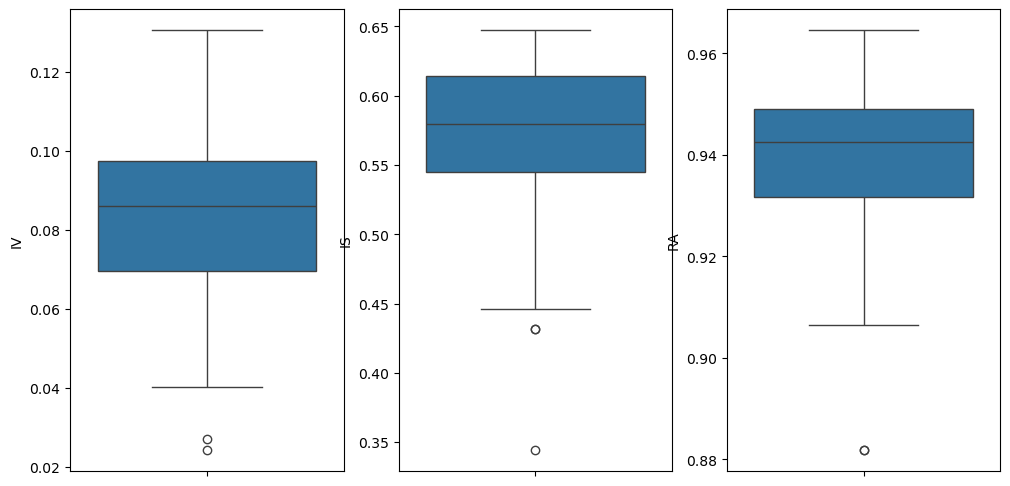

In [91]:
# box plot to verify the outliers in IV, IS, and RA
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
sns.boxplot(data=merged_data['IV'], ax=ax[0])
sns.boxplot(data=merged_data['IS'], ax=ax[1])
sns.boxplot(data=merged_data['RA'], ax=ax[2])
plt.show()

In [92]:
# summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()
summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       53.0  0.080466  0.022129  0.024172  0.067942  0.082638  0.093785   
UK        36.0  0.088307  0.017596  0.053677  0.075609  0.087177  0.098561   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  48.0  0.574327  ...  0.614767  0.647358  50.0  0.940170   
UK        0.130562  34.0  0.567904  ...  0.613489  0.645810  34.0  0.937674   

                                                                     
              std       min       25%       50%       75%       max  
location                                                             
ITA       0.01533  0.881815  0.931972  0.942574  0.950680  0.964584  
UK        0.01699  0.881815  0.930985  0.942574  0.947245  0.962952  

[2 rows x 24 columns]

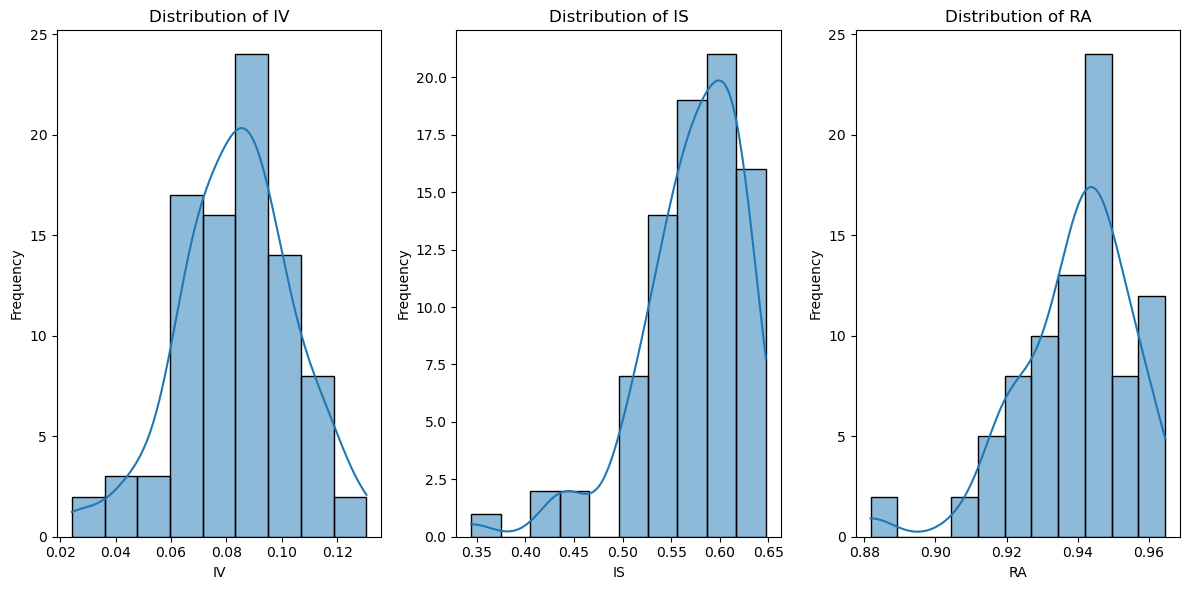

In [93]:
# distribution of IV, IS, and RA
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title('Distribution of IV')
plt.xlabel('IV')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title('Distribution of RA')
plt.xlabel('RA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [94]:
# compare the variables between ITA and UK
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [95]:
print('Test results for IV by location:', iv_ttest)
print('Test results for IS by location:', is_utest)
print('Test results for RA by location:', ra_utest)

Test results for IV by location: TtestResult(statistic=-1.7772445658632352, pvalue=0.07902284498496115, df=87.0)
Test results for IS by location: MannwhitneyuResult(statistic=869.5, pvalue=0.6178431739272754)
Test results for RA by location: MannwhitneyuResult(statistic=916.5, pvalue=0.5474926482394891)


------------------------

__Sleep-wake patterns over time__

_Midsleep_

In [96]:
# n of days by day_after_flight
count_day_after_flight = df['day_after_flight'].value_counts()

In [97]:
# filter the data by the days after the flight (15)
sleep_bydays_after_flight = df[df['day_after_flight'] <= 15]

In [98]:
# download the data df to a csv file
#df.to_csv(fpath + '\\df1.csv', index=False)

# download the sleep_bydays_after_flight data to a csv file
#sleep_bydays_after_flight.to_csv(fpath + '\\sleep_bydays_after_flight1.csv', index=False)

In [99]:
# group by location
sleep_bydays_after_flight_uk = sleep_bydays_after_flight[sleep_bydays_after_flight['location'] == 'UK']
sleep_bydays_after_flight_ita = sleep_bydays_after_flight[sleep_bydays_after_flight['location'] == 'ITA']

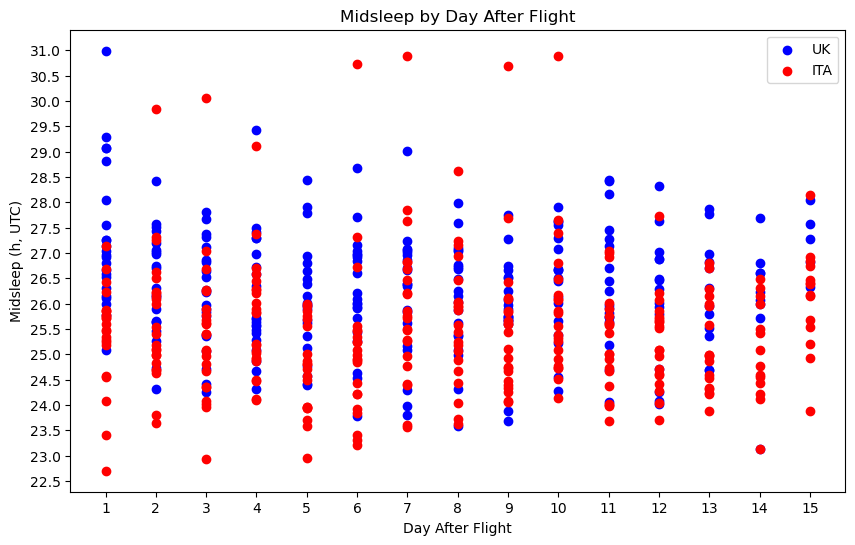

In [100]:
plt.figure(figsize=(10, 6))
plt.scatter(sleep_bydays_after_flight_uk['day_after_flight'], sleep_bydays_after_flight_uk['midsleep_h_UTC'], label='UK', color='blue')
plt.scatter(sleep_bydays_after_flight_ita['day_after_flight'], sleep_bydays_after_flight_ita['midsleep_h_UTC'], label='ITA', color='red')
plt.xlabel('Day After Flight')
plt.ylabel('Midsleep (h, UTC)')
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.title('Midsleep by Day After Flight')
plt.legend()
plt.show()

In [101]:
# new column with the day after flight category
df['day_after_flight_category'] = pd.cut(df['day_after_flight'], bins=[0, 5, 10, 15, max(df['day_after_flight'])], labels=['1-3 days', '4-6 days','7-9 days', '>10 days'])
df1['day_after_flight_category'] = pd.cut(df1['day_after_flight'], bins=[0, 5, 10, 15, max(df1['day_after_flight'])], labels=['1-3 days', '4-6 days','7-9 days', '>10 days'])
df2['day_after_flight_category'] = pd.cut(df2['day_after_flight'], bins=[0, 5, 10, 15, max(df2['day_after_flight'])], labels=['1-3 days', '4-6 days','7-9 days', '>10 days'])
df3['day_after_flight_category'] = pd.cut(df3['day_after_flight'], bins=[0, 5, 10, 15, max(df3['day_after_flight'])], labels=['1-3 days', '4-6 days','7-9 days', '>10 days'])

C:\Users\gg00642\AppData\Local\Temp\ipykernel_11180\1174460581.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['day_after_flight_category'] = pd.cut(df3['day_after_flight'], bins=[0, 5, 10, 15, max(df3['day_after_flight'])], labels=['1-3 days', '4-6 days','7-9 days', '>10 days'])


In [102]:
# new column with the day after flight category 1-3 days and >3 days
df['day_after_flight_category_simple'] = pd.cut(df['day_after_flight'], bins=[0, 4, max(df['day_after_flight'])], labels=['1-4 days', '>4 days'])
df1['day_after_flight_category_simple'] = pd.cut(df1['day_after_flight'], bins=[0, 4, max(df1['day_after_flight'])], labels=['1-4 days', '>4 days'])
df2['day_after_flight_category_simple'] = pd.cut(df2['day_after_flight'], bins=[0, 4, max(df2['day_after_flight'])], labels=['1-4 days', '>4 days'])
df3['day_after_flight_category_simple'] = pd.cut(df3['day_after_flight'], bins=[0, 4, max(df3['day_after_flight'])], labels=['1-4 days', '>4 days'])

C:\Users\gg00642\AppData\Local\Temp\ipykernel_11180\2053516375.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['day_after_flight_category_simple'] = pd.cut(df3['day_after_flight'], bins=[0, 4, max(df3['day_after_flight'])], labels=['1-4 days', '>4 days'])


In [103]:
# linear regression model with categorical variables
model1a = smf.ols('midsleep_h_UTC ~ C(day_after_flight_category)', data=df).fit()

print(model1a.summary())

                            OLS Regression Results                            
Dep. Variable:         midsleep_h_UTC   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9053
Date:                Tue, 04 Feb 2025   Prob (F-statistic):              0.438
Time:                        16:35:35   Log-Likelihood:                -1052.5
No. Observations:                 638   AIC:                             2113.
Df Residuals:                     634   BIC:                             2131.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [104]:
# linear regression model with categorical variables
model1b = smf.ols('midsleep_h_UTC ~ C(day_after_flight_category_simple)', data=df).fit()

print(model1b.summary())

                            OLS Regression Results                            
Dep. Variable:         midsleep_h_UTC   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     5.097
Date:                Tue, 04 Feb 2025   Prob (F-statistic):             0.0243
Time:                        16:35:35   Log-Likelihood:                -1051.3
No. Observations:                 638   AIC:                             2107.
Df Residuals:                     636   BIC:                             2116.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [105]:
model1c = smf.mixedlm('midsleep_h_UTC ~ location * day_after_flight_category_simple', df, groups=df['day_after_flight']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1c.summary())

                                Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               midsleep_h_UTC
No. Observations:               638                   Method:                           REML          
No. Groups:                     46                    Scale:                            1.3978        
Min. group size:                1                     Log-Likelihood:                   -1021.3168    
Max. group size:                46                    Converged:                        Yes           
Mean group size:                13.9                                                                  
------------------------------------------------------------------------------------------------------
                                                           Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

In [106]:
# Fit a mixed-effects model with random intercepts for each day after flight
model2a = smf.mixedlm('midsleep_h_UTC ~ C(location) + photoperiod + C(DST_0)', data=df, groups=df['day_after_flight'], re_formula='~1').fit()

print(model2a.summary())

            Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: midsleep_h_UTC
No. Observations:  638     Method:             REML          
No. Groups:        46      Scale:              1.1319        
Min. group size:   1       Log-Likelihood:     -957.1061     
Max. group size:   46      Converged:          Yes           
Mean group size:   13.9                                      
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept         26.497    0.251 105.730 0.000 26.006 26.989
C(location)[T.UK]  0.778    0.086   9.005 0.000  0.609  0.947
C(DST_0)[T.1]     -0.832    0.134  -6.187 0.000 -1.096 -0.569
photoperiod       -0.048    0.025  -1.899 0.058 -0.098  0.002
Group Var          0.034    0.021                            



In [107]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model2b = smf.mixedlm('midsleep_h_UTC ~ C(location) + photoperiod + C(DST_0) + photoperiod*C(location)', 
                      data=df, groups=df['day_after_flight'], re_formula='~1').fit()

print(model2b.summary())

                 Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     midsleep_h_UTC
No. Observations:     638         Method:                 REML          
No. Groups:           46          Scale:                  1.1336        
Min. group size:      1           Log-Likelihood:         -959.6010     
Max. group size:      46          Converged:              Yes           
Mean group size:      13.9                                              
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     26.448    0.331 79.884 0.000 25.799 27.096
C(location)[T.UK]              0.864    0.382  2.260 0.024  0.115  1.613
C(DST_0)[T.1]                 -0.834    0.135 -6.182 0.000 -1.099 -0.570
photoperiod                   -0.044    0.032 -1.378 0.168 -0.106  0.

In [108]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model2c = smf.mixedlm('midsleep_h_UTC ~ C(day_after_flight_category_simple) + C(location) + photoperiod + C(DST_0) + photoperiod*C(location)', 
                      data=df, groups=df['day_after_flight'], re_formula='~1').fit()

print(model2c.summary())

                          Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          midsleep_h_UTC
No. Observations:            638              Method:                      REML          
No. Groups:                  46               Scale:                       1.1351        
Min. group size:             1                Log-Likelihood:              -959.7080     
Max. group size:             46               Converged:                   Yes           
Mean group size:             13.9                                                        
-----------------------------------------------------------------------------------------
                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                      26.608    0.349 76.228 0.000 25.924 27.292
C(day_after_flight_category_simple)[

In [109]:
# calculate log-likelihood of model2a
ll_model2a = model2a.llf
ll_model2b = model2b.llf

# calculate likelihood ratio Chi-Squared test statistic
lr_test1 = 2 * (ll_model2a - model2b.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
p_value = stats.chi2.sf(lr_test1, 2)

print('Likelihood ratio test results:')
print('Chi-Squared test statistic:', lr_test1)
print('P-value:', p_value)

Likelihood ratio test results:
Chi-Squared test statistic: 4.989881466684437
P-value: 0.08250134082558658


In [110]:
# calculate log-likelihood of model2a
ll_model2b = model2b.llf
ll_model2c = model2c.llf

# calculate likelihood ratio Chi-Squared test statistic
lr_test1 = 2 * (ll_model2b - model2c.llf)

# calculate p-value of test statistic using 2 degrees of freedom
p_value = stats.chi2.sf(lr_test1, 2)

print('Likelihood ratio test results:')
print('Chi-Squared test statistic:', lr_test1)
print('P-value:', p_value)

Likelihood ratio test results:
Chi-Squared test statistic: 0.21402592146523602
P-value: 0.8985140275147746


In [111]:
# calculate log-likelihood of model2a
ll_model2a = model2a.llf
ll_model2c = model2c.llf

# calculate likelihood ratio Chi-Squared test statistic
lr_test1 = 2 * (ll_model2a - model2c.llf)

# calculate p-value of test statistic using 2 degrees of freedom
p_value = stats.chi2.sf(lr_test1, 2)

print('Likelihood ratio test results:')
print('Chi-Squared test statistic:', lr_test1)
print('P-value:', p_value)

Likelihood ratio test results:
Chi-Squared test statistic: 5.203907388149673
P-value: 0.07412861202056689


In [112]:
coef_df2 = pd.DataFrame({'coef': model2a.params.values, 'p-value': model2a.pvalues.values, '0.025': model2a.conf_int()[0], '0.975': model2a.conf_int()[1]})
coef_df2

,coef,p-value,0.025,0.975
Intercept,26.497393,0.000000e+00,26.006200,26.988585
C(location)[T.UK],0.777910,2.151710e-19,0.608601,0.947220
C(DST_0)[T.1],-0.832116,6.139660e-10,-1.095728,-0.568504
photoperiod,-0.047999,5.761876e-02,-0.097549,0.001552
Group Var,0.029737,1.338325e-01,-0.009141,0.068615


In [113]:
#drop non significant variables
coef_df2 = coef_df2.drop('Intercept')
coef_df2 = coef_df2.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_11180\2758114602.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.ST]', 'Photoperiod'])


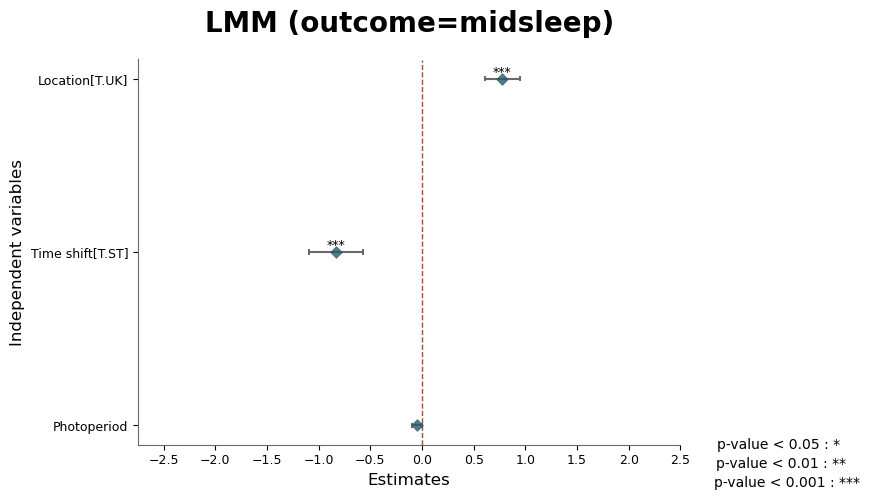

In [114]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_df2.index, data=coef_df2, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_df2.shape[0]):
    plt.plot([coef_df2['0.025'].iloc[i], coef_df2['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_df2['0.025'].iloc[i], coef_df2['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_df2['0.975'].iloc[i], coef_df2['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_df2.shape[0]):
    if coef_df2['p-value'].iloc[i] < 0.001:
        plt.text(coef_df2['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_df2['p-value'].iloc[i] < 0.01:
        plt.text(coef_df2['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_df2['p-value'].iloc[i] < 0.055:
        plt.text(coef_df2['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=midsleep)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.ST]', 'Photoperiod'])

plt.show()

<Figure size 800x600 with 0 Axes>

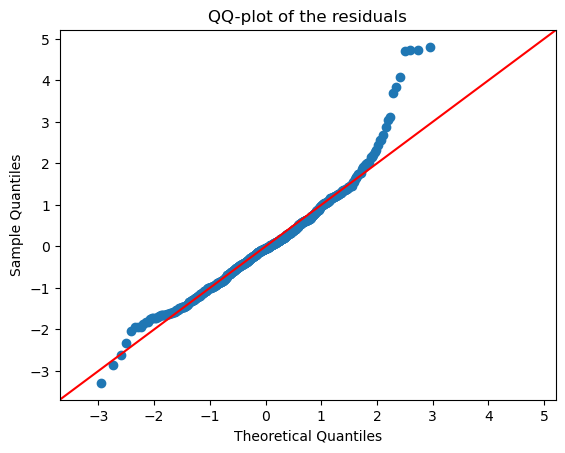

In [115]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model2b.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [116]:
residualsY = model2b.resid 
predictedY = model2b.fittedvalues

In [117]:
# Breusch-Pagan test for homoscedasticity
bp_testY = het_breuschpagan(residualsY, model2b.model.exog)

# results of the Breusch-Pagan test
bp_statY, bp_pvalY, _, _ = bp_testY
print(f'Breusch-Pagan statistic: {bp_statY}, p-value: {bp_pvalY}')
if bp_pvalY > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 8.446752481945317, p-value: 0.07651777144194902
The residuals are homoscedastic (fail to reject H0).


In [118]:
# Durbin-Watson test for autocorrelation
durbin_watson_testY = durbin_watson(residualsY)

print('Durbin-Watson test:', durbin_watson_testY)

Durbin-Watson test: 1.302913346247417


In [119]:
# The Durbin-Watson test statistic is close to 2, which indicates that there is no significant autocorrelation in the residuals

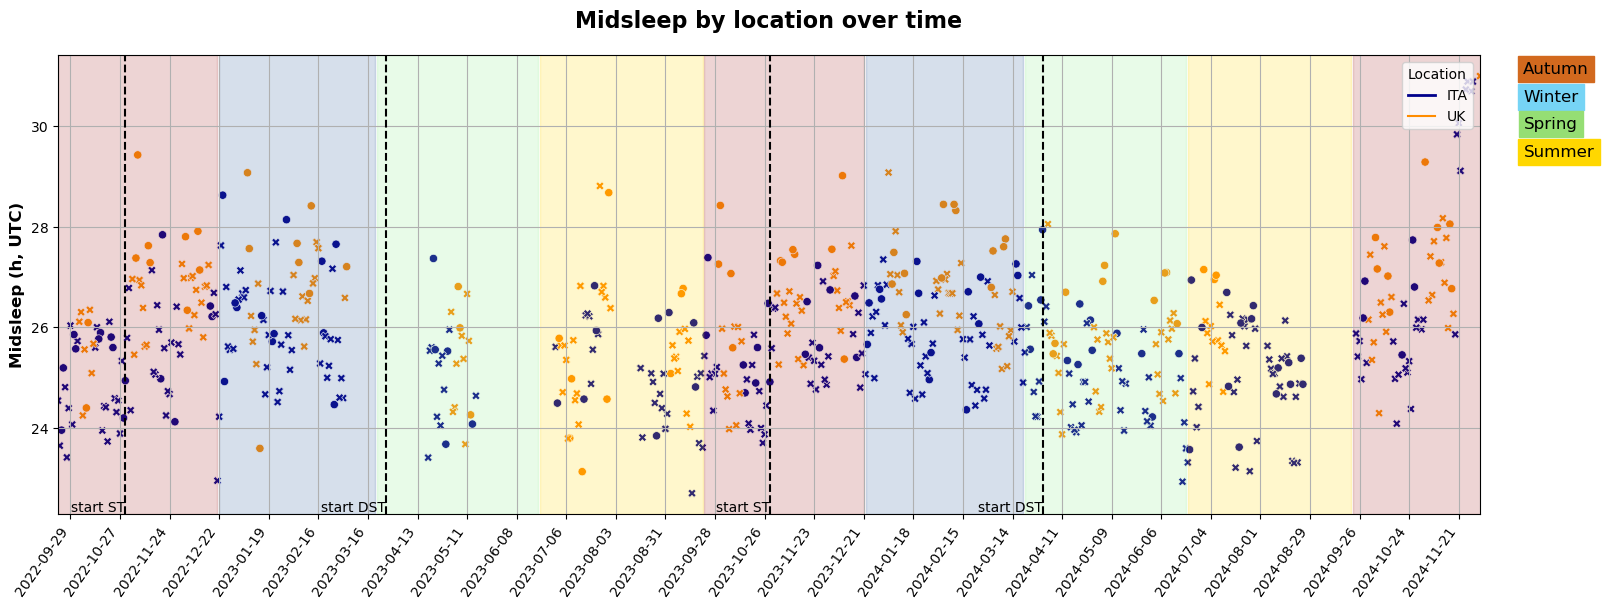

In [120]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h_UTC', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h, UTC)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

plt.show()

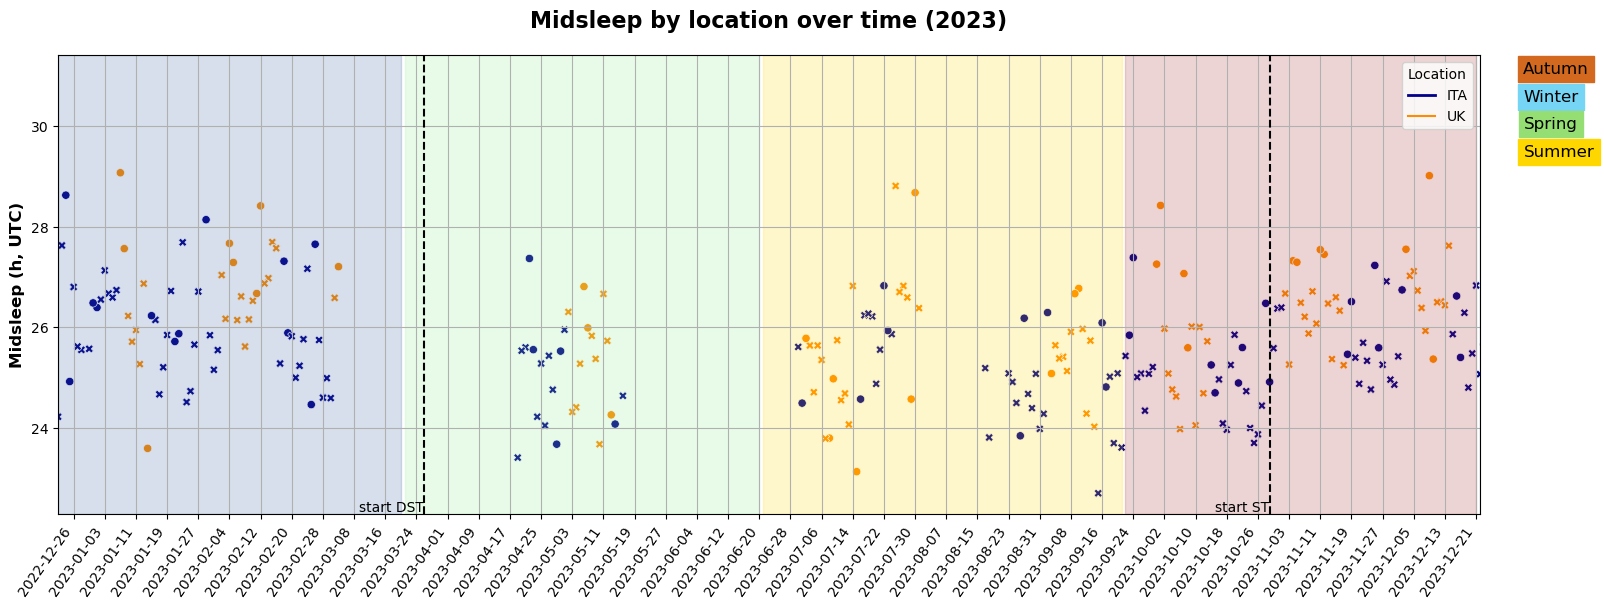

In [121]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h_UTC', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time (2023)', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h, UTC)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min() + pd.DateOffset(months=3), df['date'].min() + pd.DateOffset(months=15))
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.gca().xaxis.set_major_locator(MultipleLocator(8)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
#plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

plt.show()

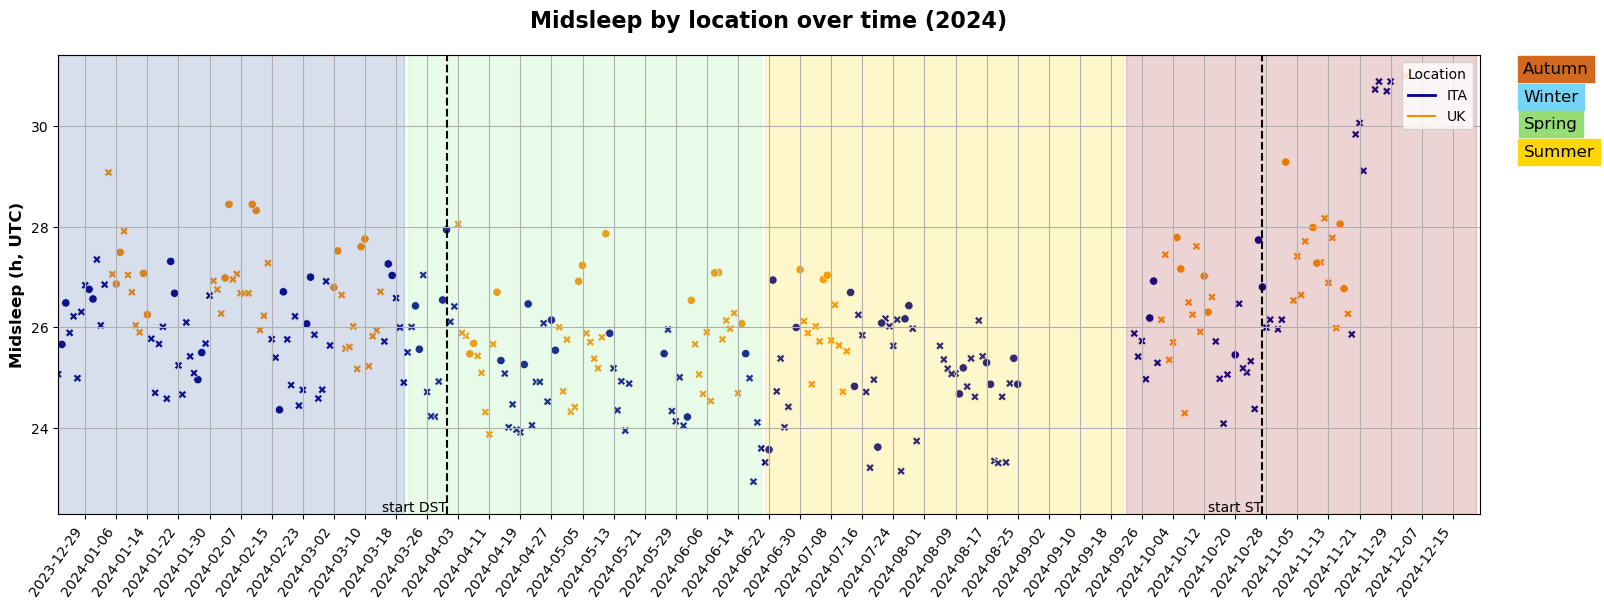

In [122]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h_UTC', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time (2024)', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h, UTC)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min() + pd.DateOffset(months=15), df['date'].min() + pd.DateOffset(months=27))
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.gca().xaxis.set_major_locator(MultipleLocator(8)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
#plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

plt.show()

_Phase (wake up time - sunrise)_

In [123]:
#remove outliers of phase from df2
df2 = df2[(np.abs(stats.zscore(df2['phase'])) < 3)]

In [124]:
# test the skewness of the phase data
skewness = skew(df2['phase'])

print(f"Index of skewness: {skewness}")

Index of skewness: 0.5635803789788169


In [125]:
# test the kurtosis of the phase data
kurtosis_value = kurtosis(df2['phase'])

print(f"Index of kurtosis: {kurtosis_value}")

Index of kurtosis: -0.30809733405893924


In [126]:
#phase_data = df2['phase'].values.reshape(-1, 1)

# apply the Yeo-Johnson transformation
#pt = PowerTransformer(method='yeo-johnson')
#phase_transformed = pt.fit_transform(phase_data)

In [127]:
# add the transformed phase to the dataframe 
#df2['phase_transformed'] = phase_transformed

In [128]:
# test the best distribution for the phase data
distributions = ['norm', 'gamma', 'lognorm', 'expon']
best_fit_results = {}

In [129]:
# Filter out invalid values (e.g., negative values or zeros) for distributions that require positive values
valid_phase = df2["phase"][df2["phase"] > 0]

for dist_name in distributions:
    dist = getattr(stats, dist_name)
    if dist_name in ['gamma', 'lognorm', 'expon']:
        params = dist.fit(valid_phase)
        ks_stat, ks_pval = stats.kstest(valid_phase, dist_name, args=params)
    else:
        params = dist.fit(df2["phase"])
        ks_stat, ks_pval = stats.kstest(df2["phase"], dist_name, args=params)
    best_fit_results[dist_name] = ks_stat  # save the KS statistic

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\scipy\stats\_continuous_distns.py:6545: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


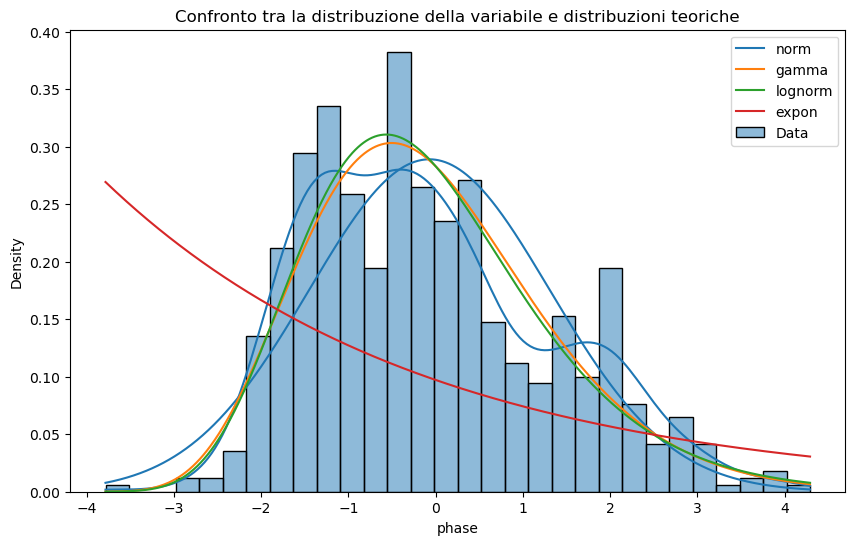

In [130]:
# plot of the best fit results
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df2["phase"], bins=30, kde=True, stat="density", label="Data", ax=ax)

x = np.linspace(df2["phase"].min(), df2["phase"].max(), 1000)

# Disegniamo le distribuzioni teoriche
for dist_name in best_fit_results.keys():
    dist = getattr(stats, dist_name)
    params = dist.fit(df2["phase"])
    pdf = dist.pdf(x, *params)
    ax.plot(x, pdf, label=f"{dist_name}")

ax.legend()
ax.set_title("Confronto tra la distribuzione della variabile e distribuzioni teoriche")
plt.show()

In [131]:
# Shapiro-Wilk test for the transformed phase
shapiro_test_phase = stats.shapiro(df2['phase'])
shapiro_test_phase

ShapiroResult(statistic=0.9639434844820087, pvalue=2.4866597902004143e-11)

In [132]:
# linear regression model with categorical variables
model1a = smf.ols('phase ~ C(day_after_flight_category)', data=df2).fit()

print(model1a.summary())

                            OLS Regression Results                            
Dep. Variable:                  phase   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     2.909
Date:                Tue, 04 Feb 2025   Prob (F-statistic):             0.0340
Time:                        16:35:38   Log-Likelihood:                -1094.1
No. Observations:                 631   AIC:                             2196.
Df Residuals:                     627   BIC:                             2214.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [133]:
# linear regression model with categorical variables
model1b = smf.ols('phase ~ C(day_after_flight_category_simple)', data=df2).fit()

print(model1b.summary())

                            OLS Regression Results                            
Dep. Variable:                  phase   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     4.859
Date:                Tue, 04 Feb 2025   Prob (F-statistic):             0.0279
Time:                        16:35:38   Log-Likelihood:                -1096.1
No. Observations:                 631   AIC:                             2196.
Df Residuals:                     629   BIC:                             2205.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [134]:
model1c = smf.mixedlm('phase ~ location * C(day_after_flight_category)', df2, groups=df2['day_after_flight']).fit(method='powell')

print(model1c.summary())

                              Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               phase     
No. Observations:               631                   Method:                           REML      
No. Groups:                     46                    Scale:                            1.6752    
Min. group size:                1                     Log-Likelihood:                   -1061.0476
Max. group size:                45                    Converged:                        Yes       
Mean group size:                13.7                                                              
--------------------------------------------------------------------------------------------------
                                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------------
Intercept                                

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [135]:
# Fit a mixed-effects model with random intercepts for each day after flight
# re_formula="~1": This specifies that the random effects are independent and only include a random intercept for each group 
# i.e. each group has its own intercept, but the slopes are assumed to be the same across groups
model2a = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_0)', data=df2, groups=df2['day_after_flight'], re_formula='~1').fit()

print(model2a.summary())

            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   phase    
No. Observations:   631       Method:               REML     
No. Groups:         46        Scale:                0.9862   
Min. group size:    1         Log-Likelihood:       -901.0081
Max. group size:    45        Converged:            Yes      
Mean group size:    13.7                                     
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept         -4.773    0.235 -20.322 0.000 -5.234 -4.313
C(location)[T.UK]  0.965    0.081  11.921 0.000  0.807  1.124
C(DST_0)[T.1]     -0.643    0.126  -5.114 0.000 -0.890 -0.397
photoperiod        0.400    0.024  16.816 0.000  0.353  0.447
Group Var          0.015    0.016                            



In [136]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model2b = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_0) + photoperiod*C(location)', data=df2, groups=df2['day_after_flight'], re_formula='~1').fit()

print(model2b.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       phase    
No. Observations:       631           Method:                   REML     
No. Groups:             46            Scale:                    0.9844   
Min. group size:        1             Log-Likelihood:           -902.4799
Max. group size:        45            Converged:                Yes      
Mean group size:        13.7                                             
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                     -4.477    0.308 -14.558 0.000 -5.080 -3.874
C(location)[T.UK]              0.445    0.358   1.241 0.215 -0.258  1.147
C(DST_0)[T.1]                 -0.630    0.126  -5.005 0.000 -0.877 -0.384
photoperiod                    0.374    0.029  12.680 0.

In [137]:
# calculate log-likelihood of model2a
ll_model2a = model2a.llf
ll_model2b = model2b.llf

# calculate likelihood ratio Chi-Squared test statistic
lr_test1 = 2 * (ll_model2a - model2b.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
p_value = stats.chi2.sf(lr_test1, 2)

print('Likelihood ratio test results:')
print('Chi-Squared test statistic:', lr_test1)
print('P-value:', p_value)

Likelihood ratio test results:
Chi-Squared test statistic: 2.9436940485002197
P-value: 0.22950119919374556


In [138]:
coef_df2 = pd.DataFrame({'coef': model2a.params.values, 'p-value': model2a.pvalues.values, '0.025': model2a.conf_int()[0], '0.975': model2a.conf_int()[1]})
coef_df2

,coef,p-value,0.025,0.975
Intercept,-4.773461,8.241195e-92,-5.233842,-4.313079
C(location)[T.UK],0.965205,9.232373e-33,0.806509,1.123901
C(DST_0)[T.1],-0.643209,3.150643e-07,-0.889712,-0.396706
photoperiod,0.400069,1.849885e-63,0.353441,0.446697
Group Var,0.015499,3.422981e-01,-0.016490,0.047489


In [139]:
#drop non significant variables
coef_df2 = coef_df2.drop('Intercept')
coef_df2 = coef_df2.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_11180\418142113.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.ST]', 'Photoperiod'])


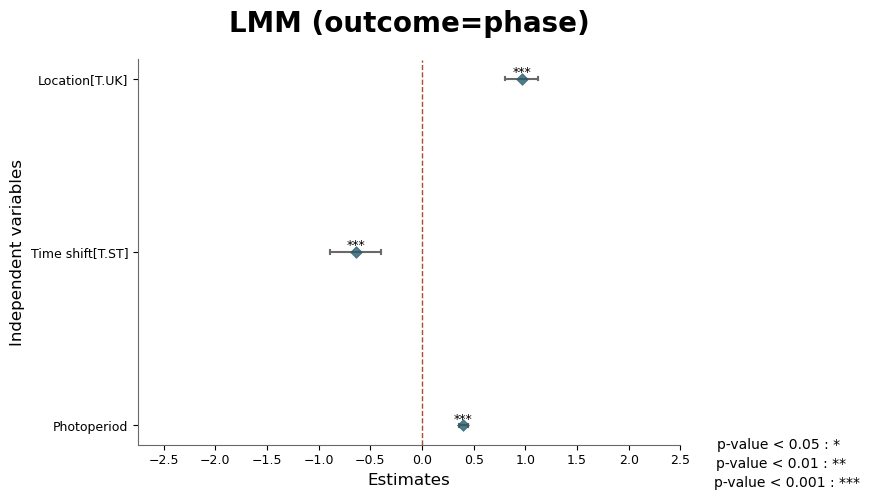

In [140]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_df2.index, data=coef_df2, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_df2.shape[0]):
    plt.plot([coef_df2['0.025'].iloc[i], coef_df2['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_df2['0.025'].iloc[i], coef_df2['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_df2['0.975'].iloc[i], coef_df2['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_df2.shape[0]):
    if coef_df2['p-value'].iloc[i] < 0.001:
        plt.text(coef_df2['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_df2['p-value'].iloc[i] < 0.01:
        plt.text(coef_df2['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_df2['p-value'].iloc[i] < 0.05:
        plt.text(coef_df2['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=phase)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.ST]', 'Photoperiod'])

plt.show()

<Figure size 800x600 with 0 Axes>

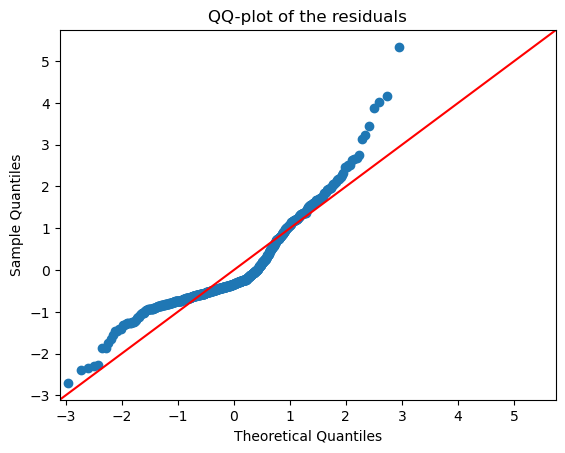

In [141]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model2a.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [142]:
residualsX = model2a.resid 
predictedX = model2a.fittedvalues

In [143]:
# Breusch-Pagan test for homoscedasticity
bp_testX = het_breuschpagan(residualsX, model2a.model.exog)

# results of the Breusch-Pagan test
bp_statX, bp_pvalX, _, _ = bp_testX
print(f'Breusch-Pagan statistic: {bp_statX}, p-value: {bp_pvalX}')
if bp_pvalX > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 16.743175651186757, p-value: 0.0007981047777433172
The residuals are heteroscedastic (reject H0).


In [144]:
# Durbin-Watson test for autocorrelation
durbin_watson_testX = durbin_watson(residualsX)

print('Durbin-Watson test:', durbin_watson_testX)

Durbin-Watson test: 0.8518557311096567


In [145]:
# Order the dat to fit the GEE model
df2 = df2.sort_values(by='date')

# define the structure of the GEE model(Autoregressive) to capture the temporal dependence
cov_str = sm.cov_struct.Autoregressive() # For longitudinal data: proximate data points exhibit stronger correlation than distant data points

# GEE model with random intercepts for each date
gee_model = smf.gee(
    'phase ~ C(location) + C(DST_0) + photoperiod + photoperiod*C(location)',
    data=df2,
    groups=df2['day_after_flight'],  # to model the intra-day post-flight correlation: 
                                     # if the day after flight affects sleep in a systematic way and if observations from the same day_after_flight are more similar to each other than observations from different days
    cov_struct=cov_str,
    family=sm.families.Gaussian()
).fit()

gee_model.summary()

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\statsmodels\genmod\cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                       phase   No. Observations:                  631
Model:                                 GEE   No. clusters:                       46
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                  45
Family:                           Gaussian   Mean cluster size:                13.7
Dependence structure:       Autoregressive   Num. iterations:                     7
Date:                     Tue, 04 Feb 2025   Scale:                           0.999
Covariance type:                    robust   Time:                         16:35:39
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -4.4561      0.555     -8.031      0.000      -5.544      -3.369
C(location)[T.UK]                 0.4599      0.492      0.935      0.350      -0.505       1.424
C(DST_0)[T.1]                    -0.6289      0.157     -4.002      0.000      -0.937      -0.321
photoperiod                       0.3720      0.053      7.085      0.000       0.269       0.475
photoperiod:C(location)[T.UK]     0.0438      0.040      1.091      0.275      -0.035       0.123
==============================================================================
Skew:                          1.2164   Kurtosis:                       2.1925
Centered skew:                 1.2232   Centered kurtosis:              2.1839
==============================================================================
"""

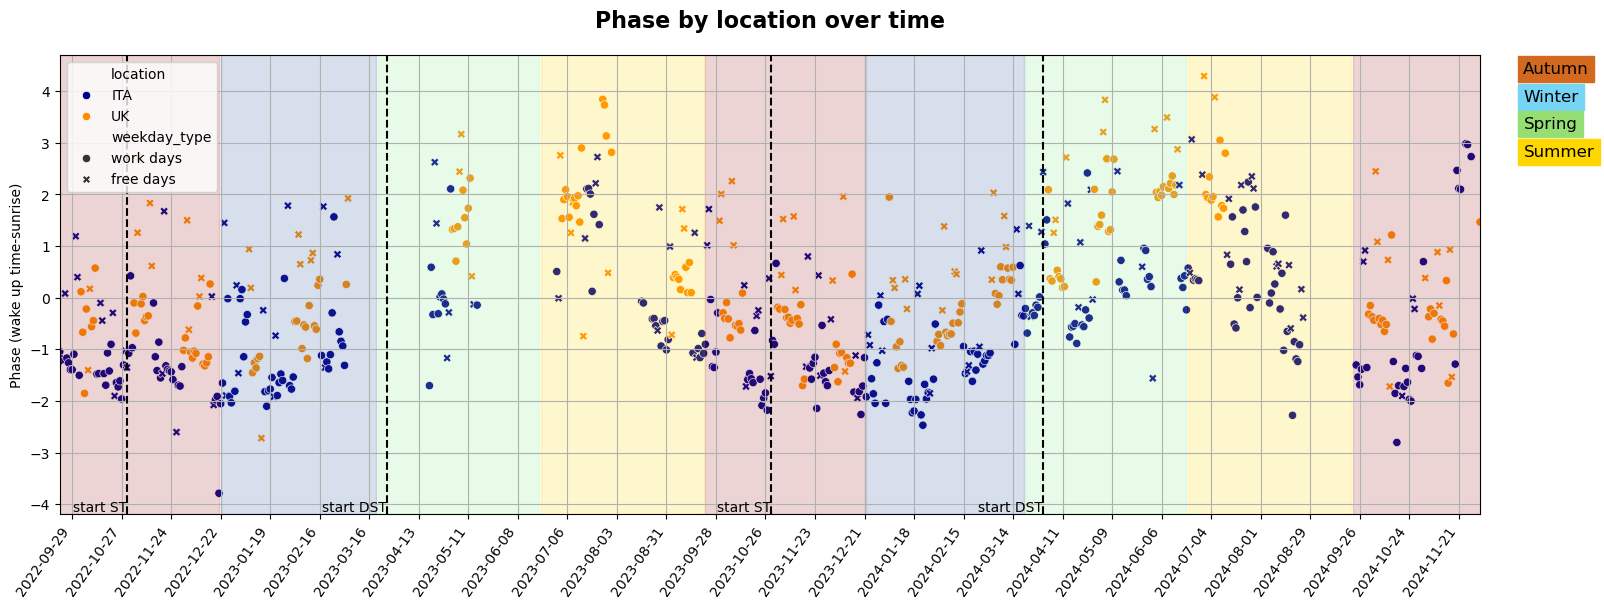

In [146]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'])
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (wake up time-sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

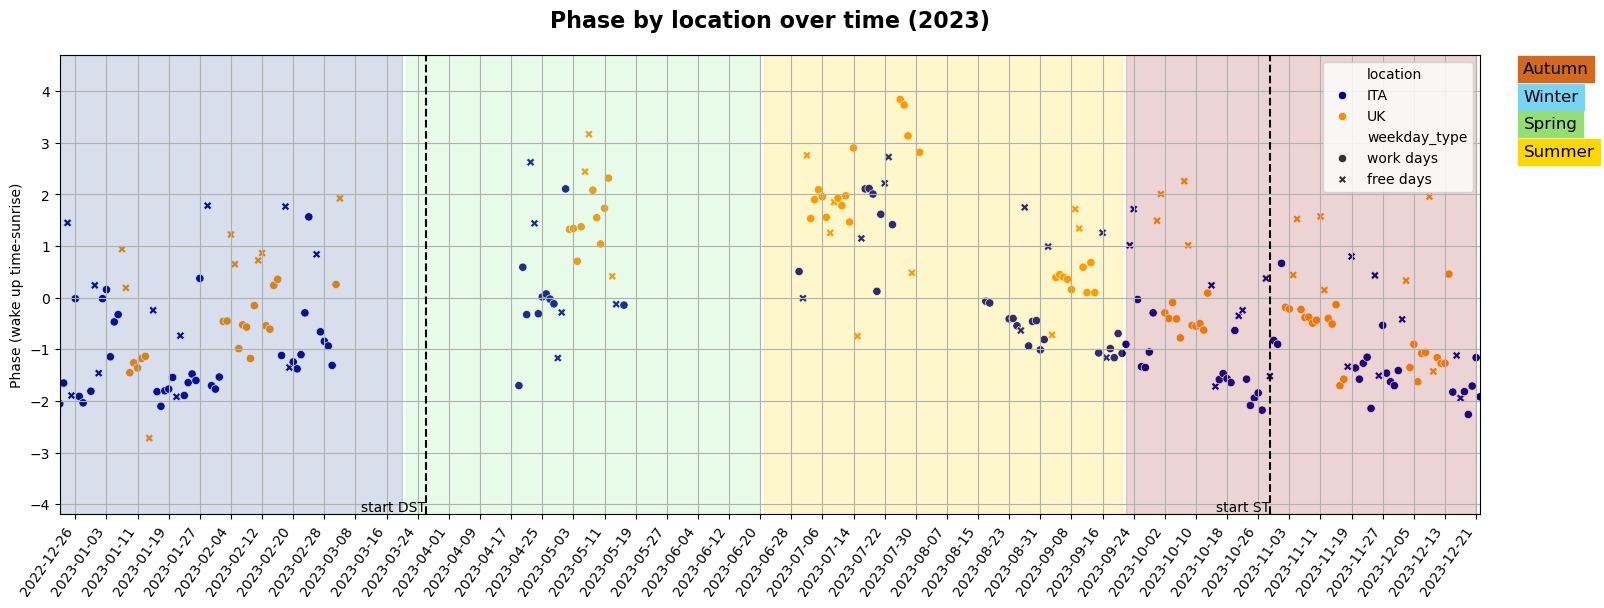

In [147]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'])
plt.title('Phase by location over time (2023)', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (wake up time-sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min() + pd.DateOffset(months=3), df['date'].min() + pd.DateOffset(months=15))
plt.gca().xaxis.set_major_locator(MultipleLocator(8)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
#plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

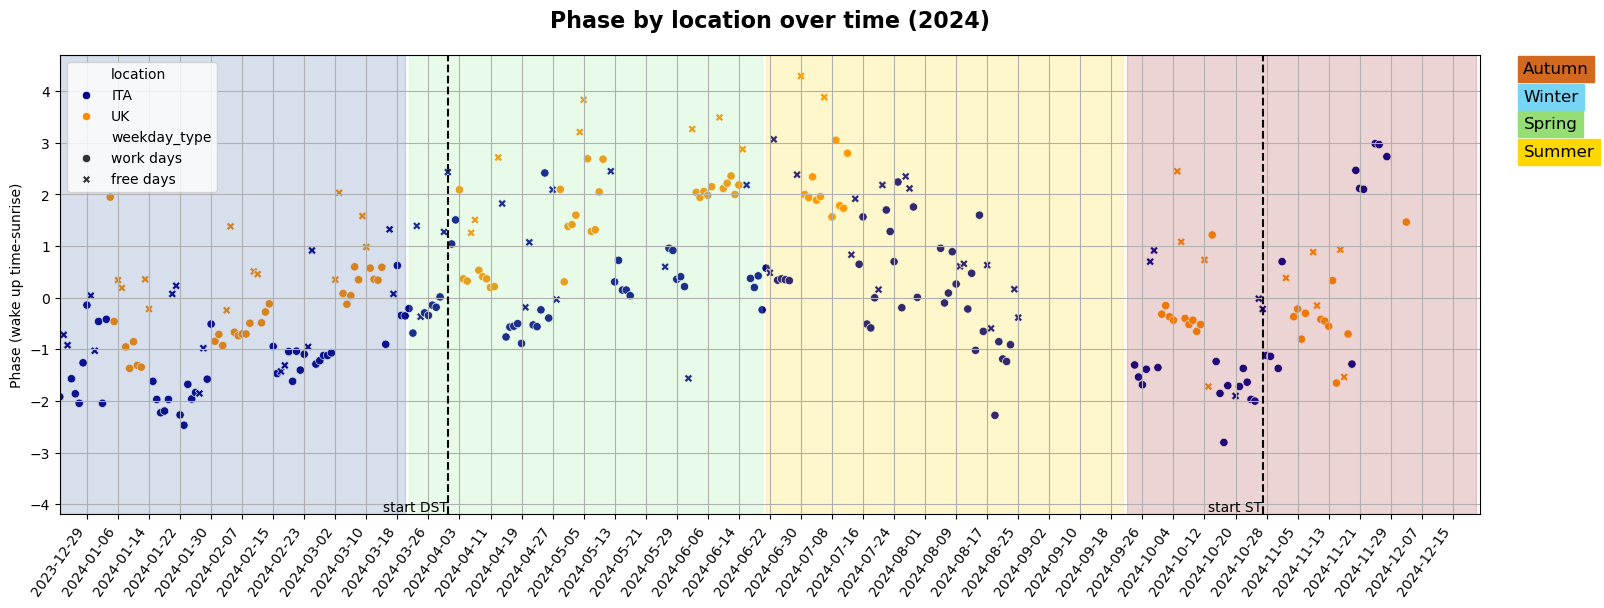

In [148]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'])
plt.title('Phase by location over time (2024)', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (wake up time-sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min() + pd.DateOffset(months=15), df['date'].min() + pd.DateOffset(months=27))
plt.gca().xaxis.set_major_locator(MultipleLocator(8)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
#plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start ST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

Wake After Sleep Onset

In [149]:
# drop the nan values in the waso_min column
df_waso_clean = df.dropna(subset=['waso'])

In [152]:
# Kruskal-Wallis test to compare the waso between the two groups
kruskal_test_flight = stats.kruskal(
    df_waso_clean[df_waso_clean['day_after_flight_category'] == '1-3 days']['waso'],
    df_waso_clean[df_waso_clean['day_after_flight_category'] == '4-6 days']['waso'],
    df_waso_clean[df_waso_clean['day_after_flight_category'] == '7-9 days']['waso'],
    df_waso_clean[df_waso_clean['day_after_flight_category'] == '>10 days']['waso']
)

kruskal_test_flight

KruskalResult(statistic=3.0795731517099947, pvalue=0.37951853703090577)

In [153]:
# Kruskal-Wallis test to compare WASO between the groups of day_after_flight
kruskal_test_flight = stats.kruskal(
    df_waso_clean[df_waso_clean['day_after_flight_category_simple'] == '1-4 days']['waso'],
    df_waso_clean[df_waso_clean['day_after_flight_category_simple'] == '>4 days']['waso'],
)

kruskal_test_flight

KruskalResult(statistic=0.5051256354689754, pvalue=0.4772565787649209)